<a href="https://colab.research.google.com/github/SohailVibeCoder/IB9AU---GenAI/blob/main/FNMA_Recovery_Multistate_Framework_colaboration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FNMA recovery intelligence — multi-state, competing-risk and collections framework (Google Colab)

This notebook implements the recovery half of the Axe project without changing the accepted EWS.

It keeps four estimands separate:

1. **Q1 — delinquency migration:** Current → 30–59 → 60–89 → first 90+ DPD.
2. **Q2 — first post-NPL resolution:** confirmed cure, clean payoff, distressed/liquidation exit or administrative exit.
3. **Q3 — recurrent post-NPL behaviour:** cure, relapse, repeat delinquency and eventual observed exit.
4. **Q4 — realised net-loss severity:** descriptive only, and only if the source-field audit passes.

The notebook restores the accepted whole-loan train/validation/test assignment, estimates on training loans, chooses among homogeneous, duration-specific and calendar-period-specific post-NPL models on validation loans, and evaluates the selected specification once on test loans. The EWS link uses only frozen scores from a fixed 24-month window ending one month before first NPL.

## Colab file layout

Before running, place these files under `MyDrive/FIP_NPL_Project/`:

- `fnma_clean_master.parquet` (preferred), or `FNMA_MF_Loan_Performance_Data_202603.csv`
- `model_outputs_grouped_loan_shuffle_24m/loan_split_assignments_seed42.csv`
- Optional EWS predictions: either `model_outputs_feature_elimination_24m/selected_vs_full_test_predictions.parquet` or `model_outputs_grouped_loan_shuffle_24m/ranking_predictions_test.parquet`

The setup cell mounts Drive and copies the large inputs to Colab's local disk for faster processing. All recovery outputs are written directly to `MyDrive/FIP_NPL_Project/model_outputs_recovery_multistate/`.

A standard CPU runtime is sufficient. High RAM is recommended; a GPU is not required.

### Claims this notebook does not make

- An administrative Fannie exit is not necessarily an economically terminal borrower outcome.
- A distressed/liquidation code does not by itself prove a positive credit loss.
- EWS-band outcome differences are associative, because no collections treatment is observed.
- Any monetary severity produced here is not labelled LGD or IFRS 9 ECL.


In [1]:
# Google Colab setup. Edit only DRIVE_PROJECT_DIR if your Drive folder differs.
import importlib.util
import os
import shutil
import subprocess
import sys
import time
from pathlib import Path

from google.colab import drive

drive.mount("/content/drive")

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/FIP_NPL_Project")
LOCAL_PROJECT_DIR = Path("/content/FIP_NPL_Project")
DRIVE_OUTPUT_DIR = DRIVE_PROJECT_DIR / "model_outputs_recovery_multistate"
LOCAL_PROJECT_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if importlib.util.find_spec("pyarrow") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyarrow"])


def first_existing(candidates, label, required=True):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    if required:
        searched = "\n".join(f"  - {candidate}" for candidate in candidates)
        raise FileNotFoundError(f"Could not find {label}. Searched:\n{searched}")
    return None


def copy_to_local(source, destination):
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists() and destination.stat().st_size == source.stat().st_size:
        print(f"Already staged: {destination.name}")
        return destination
    started = time.time()
    print(f"Copying {source.name} to Colab local disk ({source.stat().st_size / 2**30:.2f} GiB)...")
    shutil.copy2(source, destination)
    print(f"Copied in {(time.time() - started) / 60:.1f} minutes: {destination}")
    return destination


drive_source = first_existing([
    DRIVE_PROJECT_DIR / "fnma_clean_master.parquet",
    DRIVE_PROJECT_DIR / "FNMA_MF_Loan_Performance_Data_202603.csv",
], "untruncated Fannie source")

drive_split = first_existing([
    DRIVE_PROJECT_DIR / "model_outputs_grouped_loan_shuffle_24m" / "loan_split_assignments_seed42.csv",
    DRIVE_PROJECT_DIR / "model_outputs_feature_elimination_24m" / "loan_split_assignments_seed42.csv",
], "accepted loan split")

drive_predictions = first_existing([
    DRIVE_PROJECT_DIR / "model_outputs_feature_elimination_24m" / "selected_vs_full_test_predictions.parquet",
    DRIVE_PROJECT_DIR / "model_outputs_grouped_loan_shuffle_24m" / "ranking_predictions_test.parquet",
], "frozen EWS predictions", required=False)

local_source = copy_to_local(drive_source, LOCAL_PROJECT_DIR / drive_source.name)
local_split = copy_to_local(drive_split, LOCAL_PROJECT_DIR / "inputs" / drive_split.name)
local_predictions = None
if drive_predictions is not None:
    local_predictions = copy_to_local(
        drive_predictions, LOCAL_PROJECT_DIR / "inputs" / drive_predictions.name
    )
else:
    print("Optional EWS prediction file not found. Section 13 will be skipped cleanly.")

os.environ["FIP_PROJECT_DIR"] = str(LOCAL_PROJECT_DIR)
os.environ["FIP_RECOVERY_OUTPUT_DIR"] = str(DRIVE_OUTPUT_DIR)
os.environ["FIP_CLEAN_SOURCE"] = str(local_source)
os.environ["FIP_SPLIT_PATH"] = str(local_split)
if local_predictions is not None:
    os.environ["FIP_EWS_PREDICTIONS_PATH"] = str(local_predictions)

print("\nColab staging complete")
print(f"Source: {local_source}")
print(f"Split: {local_split}")
print(f"Predictions: {local_predictions if local_predictions else 'not supplied'}")
print(f"Outputs: {DRIVE_OUTPUT_DIR}")


Mounted at /content/drive
Copying fnma_clean_master.parquet to Colab local disk (0.07 GiB)...
Copied in 0.0 minutes: /content/FIP_NPL_Project/fnma_clean_master.parquet
Copying loan_split_assignments_seed42.csv to Colab local disk (0.00 GiB)...
Copied in 0.0 minutes: /content/FIP_NPL_Project/inputs/loan_split_assignments_seed42.csv
Copying ranking_predictions_test.parquet to Colab local disk (0.01 GiB)...
Copied in 0.0 minutes: /content/FIP_NPL_Project/inputs/ranking_predictions_test.parquet

Colab staging complete
Source: /content/FIP_NPL_Project/fnma_clean_master.parquet
Split: /content/FIP_NPL_Project/inputs/loan_split_assignments_seed42.csv
Predictions: /content/FIP_NPL_Project/inputs/ranking_predictions_test.parquet
Outputs: /content/drive/MyDrive/FIP_NPL_Project/model_outputs_recovery_multistate


In [2]:
from pathlib import Path
try:
    from IPython.display import display, Markdown
except ImportError:  # Allows non-notebook structural tests.
    display = print
    Markdown = str
import gc
import hashlib
import json
import math
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 200)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Edit FIP_PROJECT_DIR, or set it as an environment variable.
PROJECT_DIR = Path(os.environ.get(
    "FIP_PROJECT_DIR",
    Path.home() / "Documents" / "FIP_NPL_Project",
)).expanduser()
OUTPUT_DIR = Path(os.environ.get(
    "FIP_RECOVERY_OUTPUT_DIR",
    PROJECT_DIR / "model_outputs_recovery_multistate",
)).expanduser()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CUSTOM_SOURCE = os.environ.get("FIP_CLEAN_SOURCE")
CUSTOM_SPLIT = os.environ.get("FIP_SPLIT_PATH")
CUSTOM_EWS_PREDICTIONS = os.environ.get("FIP_EWS_PREDICTIONS_PATH")

SOURCE_CANDIDATES = [
    PROJECT_DIR / "fnma_clean_master.parquet",
    PROJECT_DIR / "FNMA_MF_Loan_Performance_Data_202603.csv",
]
SPLIT_CANDIDATES = [
    PROJECT_DIR / "model_outputs_grouped_loan_shuffle_24m" / "loan_split_assignments_seed42.csv",
    PROJECT_DIR / "model_outputs_feature_elimination_24m" / "loan_split_assignments_seed42.csv",
]
EWS_PREDICTION_CANDIDATES = [
    PROJECT_DIR / "model_outputs_feature_elimination_24m" / "selected_vs_full_test_predictions.parquet",
    PROJECT_DIR / "model_outputs_grouped_loan_shuffle_24m" / "ranking_predictions_test.parquet",
]

SPLIT_SEED = 42
PRIMARY_CURE_MONTHS = 3
CURE_SENSITIVITY_MONTHS = [1, 3]
HORIZONS = [3, 6, 12, 24]
MAX_VALIDATION_HORIZON = 24
MIN_DURATION_ROW_COUNT = 20
MIN_PERIOD_ROW_COUNT = 20
MIN_SUBGROUP_CIF_LOANS = 30
CRAMERS_V_MATERIAL_THRESHOLD = 0.10
HOMOGENEOUS_PREFERENCE_TOLERANCE_TV = 0.005
BOOTSTRAP_REPS = int(os.environ.get("RECOVERY_BOOTSTRAP_REPS", "500"))
BOOTSTRAP_SEED = int(os.environ.get("RECOVERY_BOOTSTRAP_SEED", "4207"))

EXIT_MAP = {
    "Fully Paid, Matured": "EXIT_CLEAN",
    "Fully Paid, Prepaid": "EXIT_CLEAN",
    "Fully Paid, Refinance": "EXIT_CLEAN",
    "Fully Paid, Refinanced": "EXIT_CLEAN",
    "Foreclosure": "EXIT_DISTRESSED",
    "Deed-in-Lieu": "EXIT_DISTRESSED",
    "Third Party Sale": "EXIT_DISTRESSED",
    "Discounted Payoff": "EXIT_DISTRESSED",
    "Other Liquidation": "EXIT_DISTRESSED",
    "Repurchase": "EXIT_ADMIN_OTHER",
    "Substitution": "EXIT_ADMIN_OTHER",
    "Dissolution": "EXIT_ADMIN_OTHER",
    "Other": "EXIT_ADMIN_OTHER",
}

Q1_STATES = [
    "CURRENT_CLEAN", "DQ_30_59", "DQ_60_89", "NPL_90P",
    "EXIT_CLEAN", "EXIT_DISTRESSED", "EXIT_ADMIN_OTHER",
]
Q3_STATES = [
    "NPL_90P", "POST_NPL_DQ_60_89", "POST_NPL_DQ_30_59", "POST_NPL_CURRENT",
    "EXIT_CLEAN", "EXIT_DISTRESSED", "EXIT_ADMIN_OTHER",
]
ABSORBING_STATES = {"EXIT_CLEAN", "EXIT_DISTRESSED", "EXIT_ADMIN_OTHER"}
Q2_EVENTS = ["CURED_CONFIRMED", "EXIT_CLEAN", "EXIT_DISTRESSED", "EXIT_ADMIN_OTHER"]

CONFIG = {
    "project_dir": str(PROJECT_DIR),
    "output_dir": str(OUTPUT_DIR),
    "source_priority": [str(p) for p in SOURCE_CANDIDATES],
    "split_seed": SPLIT_SEED,
    "primary_cure_definition": f"{PRIMARY_CURE_MONTHS} consecutive Current months; event at confirmation",
    "cure_sensitivity_months": CURE_SENSITIVITY_MONTHS,
    "horizons_months": HORIZONS,
    "bootstrap_replicates": BOOTSTRAP_REPS,
    "bootstrap_unit": "whole loan / whole subject",
    "minimum_subgroup_cif_loans": MIN_SUBGROUP_CIF_LOANS,
    "minimum_period_state_row_transitions": MIN_PERIOD_ROW_COUNT,
    "cramers_v_material_threshold": CRAMERS_V_MATERIAL_THRESHOLD,
    "homogeneous_preference_tolerance_total_variation": HOMOGENEOUS_PREFERENCE_TOLERANCE_TV,
    "q1_states": Q1_STATES,
    "q2_events": Q2_EVENTS,
    "q3_states": Q3_STATES,
}
display(pd.Series(CONFIG, name="value").to_frame())

,value
project_dir,/content/FIP_NPL_Project
output_dir,/content/drive/MyDrive/FIP_NPL_Project/model_o...
source_priority,[/content/FIP_NPL_Project/fnma_clean_master.pa...
split_seed,42
primary_cure_definition,3 consecutive Current months; event at confirm...
cure_sensitivity_months,"[1, 3]"
horizons_months,"[3, 6, 12, 24]"
bootstrap_replicates,500
bootstrap_unit,whole loan / whole subject
minimum_subgroup_cif_loans,30


## 1. Reusable utilities and data contract

The schema adapter below is the Fannie implementation of a reusable interface. A corporate client would replace the source-column mapping, state thresholds and exit-code configuration while retaining the estimators and validation protocol.

In [3]:
def month_start(values):
    parsed = pd.to_datetime(values, errors="coerce")
    return parsed.dt.to_period("M").dt.to_timestamp()


def add_months(value, months):
    return pd.Timestamp(value).to_period("M").to_timestamp() + pd.DateOffset(months=int(months))


def month_difference(later, earlier):
    later = pd.to_datetime(later)
    earlier = pd.to_datetime(earlier)
    return (later.dt.year - earlier.dt.year) * 12 + (later.dt.month - earlier.dt.month)


def money_to_numeric(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    return pd.to_numeric(
        series.astype("string").str.replace(r"[$,()]", "", regex=True),
        errors="coerce",
    )


def last_valid(series):
    non_null = series.dropna()
    return non_null.iloc[-1] if len(non_null) else np.nan


def first_valid(series):
    non_null = series.dropna()
    return non_null.iloc[0] if len(non_null) else np.nan


def save_table(frame, filename, index=False):
    path = OUTPUT_DIR / filename
    frame.to_csv(path, index=index)
    return path


def write_json(payload, filename):
    path = OUTPUT_DIR / filename
    path.write_text(json.dumps(payload, indent=2, default=str), encoding="utf-8")
    return path


def holm_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    out = np.full(len(p), np.nan)
    valid = np.flatnonzero(np.isfinite(p))
    if not len(valid):
        return out
    order = valid[np.argsort(p[valid])]
    running = 0.0
    m = len(order)
    for rank, idx in enumerate(order):
        adjusted = min(1.0, (m - rank) * p[idx])
        running = max(running, adjusted)
        out[idx] = running
    return out


def era_label(dates):
    years = pd.to_datetime(dates).dt.year
    return pd.cut(
        years,
        bins=[-np.inf, 2008, 2011, 2019, 2021, np.inf],
        labels=["pre_2009", "gfc_2009_11", "post_gfc_2012_19", "covid_2020_21", "rates_2022_plus"],
        right=True,
    ).astype("string")


def find_first_existing(custom, candidates, label):
    if custom:
        path = Path(custom).expanduser()
        if not path.exists():
            raise FileNotFoundError(f"Configured {label} does not exist: {path}")
        return path
    for path in candidates:
        if path.exists():
            return path
    searched = "\n".join(f"  - {path}" for path in candidates)
    raise FileNotFoundError(f"Could not find {label}. Searched:\n{searched}")


def transition_tables(transitions, states):
    counts = pd.crosstab(transitions["state"], transitions["next_state"]).reindex(
        index=states, columns=states, fill_value=0
    )
    probabilities = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    for state in states:
        # A state with no observed outgoing training transitions must still have
        # a stochastic row. In Q1 this also makes first NPL terminal by design.
        if counts.loc[state].sum() == 0:
            probabilities.loc[state, state] = 1.0
    return counts.astype("int64"), probabilities.astype(float)


def matrix_long(counts, probabilities, label):
    count_long = counts.rename_axis("from_state").reset_index().melt(
        id_vars="from_state", var_name="to_state", value_name="transitions"
    )
    prob_long = probabilities.rename_axis("from_state").reset_index().melt(
        id_vars="from_state", var_name="to_state", value_name="probability"
    )
    out = count_long.merge(prob_long, on=["from_state", "to_state"], how="outer")
    out.insert(0, "matrix", label)
    return out


def file_fingerprint(path):
    stat = path.stat()
    return {"path": str(path), "size_bytes": stat.st_size, "modified_ns": stat.st_mtime_ns}

## 2. Load the untruncated clean source and audit its schema

`fnma_clean_master.parquet` is preferred. It contains the complete cleaned monthly history and the outcome fields deliberately excluded from Panel D. The raw CSV is a fallback, not the first choice.

In [4]:
SOURCE_PATH = find_first_existing(CUSTOM_SOURCE, SOURCE_CANDIDATES, "untruncated Fannie source")

RAW_REQUESTED = [
    "Loan Number", "Reporting Period Date", "rpd", "Loan Payment Status", "SDQ Indicator",
    "Liquidation/Prepayment Code", "Liquidation/Prepayment Date", "liq_date",
    "UPB - Current", "upb_cur_num", "Delinquency UPB", "dlq_upb_num",
    "Default Amount", "Sale Price", "Foreclosure Value", "Lifetime Net Credit Loss Amount",
    "Credit Event Type", "Credit Event Date", "Foreclosure Date",
]


def available_columns(path):
    if path.suffix.lower() == ".parquet":
        try:
            import pyarrow.parquet as pq
        except ImportError as exc:
            raise ImportError(
                "Reading fnma_clean_master.parquet requires pyarrow. Install it in this kernel."
            ) from exc
        return [name.strip() for name in pq.ParquetFile(path).schema.names]
    return [name.strip() for name in pd.read_csv(path, nrows=0).columns]


def load_untruncated_source(path):
    available = available_columns(path)
    selected = [name for name in RAW_REQUESTED if name in available]
    if path.suffix.lower() == ".parquet":
        frame = pd.read_parquet(path, columns=selected)
    else:
        raw_header = pd.read_csv(path, nrows=0).columns.tolist()
        usecols = [name for name in raw_header if name.strip() in set(selected)]
        frame = pd.read_csv(path, usecols=usecols, low_memory=False)
    frame.columns = frame.columns.str.strip()
    return frame, available


load_started = time.time()
df, source_columns = load_untruncated_source(SOURCE_PATH)

if "rpd" not in df.columns:
    if "Reporting Period Date" not in df.columns:
        raise KeyError("Source lacks both rpd and Reporting Period Date")
    df["rpd"] = month_start(df["Reporting Period Date"])
else:
    df["rpd"] = month_start(df["rpd"])

required = {"Loan Number", "Loan Payment Status", "rpd"}
missing_required = required - set(df.columns)
if missing_required:
    raise KeyError(f"Untruncated source lacks required fields: {sorted(missing_required)}")

df["Loan Number"] = df["Loan Number"].astype("string").str.strip()
df["Loan Payment Status"] = df["Loan Payment Status"].astype("string").str.strip()
if "SDQ Indicator" in df.columns:
    df["SDQ Indicator"] = df["SDQ Indicator"].astype("string").str.strip()
if "Liquidation/Prepayment Code" in df.columns:
    df["Liquidation/Prepayment Code"] = (
        df["Liquidation/Prepayment Code"].astype("string").str.strip().replace("", pd.NA)
    )

if "liq_date" in df.columns:
    df["liq_date"] = month_start(df["liq_date"])
elif "Liquidation/Prepayment Date" in df.columns:
    df["liq_date"] = month_start(df["Liquidation/Prepayment Date"])
else:
    df["liq_date"] = pd.NaT

numeric_aliases = {
    "upb_cur_num": ["upb_cur_num", "UPB - Current"],
    "dlq_upb_num": ["dlq_upb_num", "Delinquency UPB"],
    "default_amount_num": ["Default Amount"],
    "sale_price_num": ["Sale Price"],
    "foreclosure_value_num": ["Foreclosure Value"],
    "lifetime_net_credit_loss_num": ["Lifetime Net Credit Loss Amount"],
}
numeric_source_used = {}
for canonical, aliases in numeric_aliases.items():
    source = next((name for name in aliases if name in df.columns), None)
    numeric_source_used[canonical] = source
    df[canonical] = money_to_numeric(df[source]) if source else np.nan

if "Liquidation/Prepayment Code" not in df.columns:
    raise KeyError("Untruncated source lacks Liquidation/Prepayment Code, required for recovery outcomes")

if df["rpd"].isna().any():
    raise ValueError(f"{int(df['rpd'].isna().sum()):,} rows have invalid reporting dates")

duplicate_rows = df.duplicated(["Loan Number", "rpd"], keep=False)
if duplicate_rows.any():
    deduplicated = df.loc[duplicate_rows].drop_duplicates()
    conflicting = deduplicated.duplicated(["Loan Number", "rpd"], keep=False)
    if conflicting.any():
        examples = deduplicated.loc[conflicting, ["Loan Number", "rpd"]].drop_duplicates().head(10)
        raise ValueError(f"Conflicting duplicate loan-month keys found:\n{examples.to_string(index=False)}")
    df = df.drop_duplicates().copy()

expected_status = {"Current", "30-59 Days Delinquent", "60-89 Days Delinquent", "90+ Days Delinquent"}
unexpected_status = set(df["Loan Payment Status"].dropna().unique()) - expected_status
if unexpected_status:
    raise ValueError(f"Unexpected payment statuses: {sorted(unexpected_status)}")

df = df.sort_values(["Loan Number", "rpd"], kind="mergesort").reset_index(drop=True)
DATA_END = df["rpd"].max()

source_summary = pd.DataFrame([{
    "source": str(SOURCE_PATH),
    "rows": len(df),
    "loans": df["Loan Number"].nunique(),
    "rpd_min": df["rpd"].min(),
    "rpd_max": DATA_END,
    "load_minutes": (time.time() - load_started) / 60,
    "duplicate_rows_removed": int(duplicate_rows.sum()) if len(duplicate_rows) else 0,
}])
display(source_summary)

,source,rows,loans,rpd_min,rpd_max,load_minutes,duplicate_rows_removed
0,/content/FIP_NPL_Project/fnma_clean_master.par...,5392796,73048,2000-01-01,2026-03-01,0.404206,0


## 3. Freeze and audit the exit mapping

The mapping follows Fannie Mae's published allowable values. Unknown observed codes stop the notebook. Liquidation code and date are taken from the same source row. For a loan identifier that later reaches NPL, only an exit dated on or after first NPL is eligible as a recovery outcome; earlier exit records are saved to a dedicated audit, excluded from recovery resolution and never used to drop the later NPL loan. Administrative exits are absorbing only within this dataset; they are not treated as borrower credit losses.

In [5]:
exit_mapping = pd.DataFrame(
    [{"liquidation_code": code, "analysis_state": state} for code, state in EXIT_MAP.items()]
).sort_values(["analysis_state", "liquidation_code"])
save_table(exit_mapping, "exit_code_mapping.csv")

observed_codes = set(df.get("Liquidation/Prepayment Code", pd.Series(dtype="string")).dropna().unique())
unknown_codes = sorted(observed_codes - set(EXIT_MAP))
if unknown_codes:
    raise ValueError(
        "Observed liquidation codes are absent from the frozen Fannie mapping: "
        f"{unknown_codes}. Review the current Fannie glossary before proceeding."
    )

last_rows = (
    df.groupby("Loan Number", sort=False, as_index=False).tail(1)[["Loan Number", "rpd"]]
    .rename(columns={"rpd": "last_rpd"})
    .set_index("Loan Number")
)
first_rows = (
    df.groupby("Loan Number", sort=False, as_index=False).head(1)[["Loan Number", "rpd"]]
    .rename(columns={"rpd": "first_rpd"})
    .set_index("Loan Number")
)
first_npl = (
    df.loc[df["Loan Payment Status"].eq("90+ Days Delinquent")]
    .groupby("Loan Number", sort=False)["rpd"].min().rename("first_npl")
)
if "SDQ Indicator" in df.columns:
    first_60 = (
        df.loc[df["SDQ Indicator"].eq("Y")]
        .groupby("Loan Number", sort=False)["rpd"].min().rename("first_60_plus")
    )
else:
    first_60 = (
        df.loc[df["Loan Payment Status"].isin(["60-89 Days Delinquent", "90+ Days Delinquent"])]
        .groupby("Loan Number", sort=False)["rpd"].min().rename("first_60_plus")
    )

terminal = first_rows.join(last_rows, how="outer").join(first_npl, how="left").join(first_60, how="left")

terminal_fields = [
    "upb_cur_num", "dlq_upb_num", "default_amount_num", "sale_price_num", "foreclosure_value_num",
    "lifetime_net_credit_loss_num", "Credit Event Type", "Credit Event Date", "Foreclosure Date",
]
for field in terminal_fields:
    if field not in df.columns:
        continue
    non_null = df.loc[df[field].notna(), ["Loan Number", "rpd", field]]
    if non_null.empty:
        terminal[field] = np.nan
    else:
        values = non_null.sort_values(["Loan Number", "rpd"]).groupby("Loan Number", sort=False)[field].last()
        terminal = terminal.join(values.rename(field), how="left")

# Keep liquidation code and date on the same source row. For loans that later
# reach NPL, only an exit on or after first NPL is a valid recovery outcome.
exit_records = df.loc[df["Liquidation/Prepayment Code"].notna(), [
    "Loan Number", "rpd", "Liquidation/Prepayment Code", "liq_date"
]].copy()
exit_records["exit_category"] = exit_records["Liquidation/Prepayment Code"].map(EXIT_MAP)
exit_records["exit_event_date"] = pd.to_datetime(exit_records["liq_date"], errors="coerce")
missing_exit_date = exit_records["exit_event_date"].isna()
exit_records.loc[missing_exit_date, "exit_event_date"] = exit_records.loc[missing_exit_date, "rpd"]
exit_records["first_npl"] = exit_records["Loan Number"].map(first_npl)

pre_npl_exit_records = exit_records.loc[
    exit_records["first_npl"].notna()
    & exit_records["exit_event_date"].lt(exit_records["first_npl"])
].copy()
pre_npl_exit_records["recovery_treatment"] = (
    "excluded from post-NPL resolution; loan retained and censored unless a later valid exit exists"
)
save_table(pre_npl_exit_records, "pre_npl_exit_records_on_later_npl_loans.csv")
if len(pre_npl_exit_records):
    warnings.warn(
        f"{pre_npl_exit_records['Loan Number'].nunique()} later-NPL loans contain an earlier "
        "exit record. Those records are audited and excluded from post-NPL recovery outcomes.",
        RuntimeWarning,
    )

latest_exit = (
    exit_records.sort_values(["Loan Number", "exit_event_date", "rpd"], kind="mergesort")
    .groupby("Loan Number", as_index=False, sort=False).tail(1)
    .set_index("Loan Number")
)
for field in ["Liquidation/Prepayment Code", "liq_date", "exit_category", "exit_event_date"]:
    terminal[field] = latest_exit[field].reindex(terminal.index)

npl_mask = terminal["first_npl"].notna()
terminal.loc[npl_mask, "Liquidation/Prepayment Code"] = pd.NA
terminal.loc[npl_mask, "liq_date"] = pd.NaT
terminal.loc[npl_mask, "exit_category"] = pd.NA
terminal.loc[npl_mask, "exit_event_date"] = pd.NaT

valid_post_npl_exits = exit_records.loc[
    exit_records["first_npl"].notna()
    & exit_records["exit_event_date"].ge(exit_records["first_npl"])
].copy()
first_valid_post_npl_exit = (
    valid_post_npl_exits.sort_values(
        ["Loan Number", "exit_event_date", "rpd"], kind="mergesort"
    )
    .groupby("Loan Number", as_index=False, sort=False).head(1)
    .set_index("Loan Number")
)
for field in ["Liquidation/Prepayment Code", "liq_date", "exit_category", "exit_event_date"]:
    terminal.loc[first_valid_post_npl_exit.index, field] = first_valid_post_npl_exit[field]

terminal["state_exit_date"] = terminal["last_rpd"] + pd.DateOffset(months=1)
terminal["npl_era"] = era_label(terminal["first_npl"])

exit_before_npl = (
    terminal["first_npl"].notna() & terminal["exit_event_date"].notna()
    & terminal["exit_event_date"].lt(terminal["first_npl"])
)
if exit_before_npl.any():
    raise AssertionError("Post-NPL exit filtering failed to remove an earlier exit record")

observed_exit_audit = (
    terminal.reset_index().groupby(["Liquidation/Prepayment Code", "exit_category"], dropna=False)
    .agg(loans=("Loan Number", "nunique"))
    .reset_index().sort_values("loans", ascending=False)
)
save_table(observed_exit_audit, "observed_exit_code_audit.csv")

npl_terminal = terminal.loc[terminal["first_npl"].notna()].copy()
npl_terminal["terminal_position"] = npl_terminal["exit_category"].fillna("NO_RECORDED_EXIT")
terminal_benchmark = (
    npl_terminal["terminal_position"].value_counts(dropna=False)
    .rename_axis("recorded_terminal_position").reset_index(name="loans")
)
terminal_benchmark["share_pct"] = 100 * terminal_benchmark["loans"] / max(len(npl_terminal), 1)
save_table(terminal_benchmark, "recorded_terminal_position_after_npl.csv")

reference_counts = {
    "NPL_LOANS": 1836,
    "EXIT_CLEAN": 679,
    "EXIT_DISTRESSED": 780,
    "EXIT_ADMIN_OTHER": 30,
    "NO_RECORDED_EXIT": 347,
}
actual_counts = {"NPL_LOANS": len(npl_terminal), **npl_terminal["terminal_position"].value_counts().to_dict()}
reference_reconciliation = pd.DataFrame([
    {
        "measure": key,
        "reference": expected,
        "actual": int(actual_counts.get(key, 0)),
        "matches_reference": int(actual_counts.get(key, 0)) == expected,
    }
    for key, expected in reference_counts.items()
])
save_table(reference_reconciliation, "reference_count_reconciliation.csv")

reference_mismatch = ~reference_reconciliation["matches_reference"]
if reference_mismatch.any():
    mismatch_detail = reference_reconciliation.loc[
        reference_mismatch, ["measure", "reference", "actual"]
    ].to_dict("records")
    warnings.warn(
        "Loaded source differs from the previously reported March 2026 benchmark. "
        f"Review reference_count_reconciliation.csv before interpretation: {mismatch_detail}",
        RuntimeWarning,
    )

display(Markdown("### Recorded terminal position after first NPL — not first resolution"))
display(terminal_benchmark.round(3))
display(Markdown("### Reconciliation with the previously reported March 2026 benchmark"))
display(reference_reconciliation)
if reference_mismatch.any():
    display(Markdown(
        "**Warning:** at least one benchmark count differs. The notebook continues because "
        "a refreshed clean source may legitimately differ, but the discrepancy must be reconciled."
    ))

/tmp/ipykernel_739/1617791824.py:75: RuntimeWarning: 2 later-NPL loans contain an earlier exit record. Those records are audited and excluded from post-NPL recovery outcomes.
  warnings.warn(
/tmp/ipykernel_739/1617791824.py:159: RuntimeWarning: Loaded source differs from the previously reported March 2026 benchmark. Review reference_count_reconciliation.csv before interpretation: [{'measure': 'EXIT_CLEAN', 'reference': 679, 'actual': 677}, {'measure': 'NO_RECORDED_EXIT', 'reference': 347, 'actual': 349}]
  warnings.warn(


### Recorded terminal position after first NPL — not first resolution

,recorded_terminal_position,loans,share_pct
0,EXIT_DISTRESSED,780,42.484
1,EXIT_CLEAN,677,36.874
2,NO_RECORDED_EXIT,349,19.009
3,EXIT_ADMIN_OTHER,30,1.634


### Reconciliation with the previously reported March 2026 benchmark

,measure,reference,actual,matches_reference
0,NPL_LOANS,1836,1836,True
1,EXIT_CLEAN,679,677,False
2,EXIT_DISTRESSED,780,780,True
3,EXIT_ADMIN_OTHER,30,30,True
4,NO_RECORDED_EXIT,347,349,False


**Warning:** at least one benchmark count differs. The notebook continues because a refreshed clean source may legitimately differ, but the discrepancy must be reconciled.

## 4. Monetary and terminal-field feasibility audit

Coverage is measured among eligible resolved credit-event loans as well as across all rows. A field populated only at resolution can round to 0.0% across 5.39 million loan-months and still contain useful loan-level observations.

In [6]:
resolved_credit_event_ids = set(
    terminal.index[
        terminal["exit_category"].eq("EXIT_DISTRESSED")
        | terminal.get("Credit Event Type", pd.Series(index=terminal.index)).notna()
    ]
)

audit_fields = {
    "UPB - Current": "upb_cur_num",
    "Delinquency UPB": "dlq_upb_num",
    "Default Amount": "default_amount_num",
    "Sale Price": "sale_price_num",
    "Foreclosure Value": "foreclosure_value_num",
    "Lifetime Net Credit Loss Amount": "lifetime_net_credit_loss_num",
    "Credit Event Type": "Credit Event Type",
    "Credit Event Date": "Credit Event Date",
}
field_audit_rows = []
for published_name, canonical in audit_fields.items():
    exists = canonical in df.columns and not df[canonical].isna().all()
    if canonical in df.columns:
        populated = df[canonical].notna()
        loan_populated = set(df.loc[populated, "Loan Number"].unique())
        per_loan_unique = df.loc[populated].groupby("Loan Number")[canonical].nunique(dropna=True)
        multi_value_loans = int(per_loan_unique.gt(1).sum())
    else:
        populated = pd.Series(False, index=df.index)
        loan_populated = set()
        multi_value_loans = 0
    eligible_populated = len(resolved_credit_event_ids & loan_populated)
    field_audit_rows.append({
        "field": published_name,
        "canonical_column": canonical,
        "source_column": numeric_source_used.get(canonical, canonical),
        "column_present_in_loaded_source": (
            numeric_source_used.get(canonical) is not None
            if canonical in numeric_source_used
            else canonical in source_columns
        ),
        "has_any_value": bool(exists),
        "populated_rows": int(populated.sum()),
        "populated_loans": len(loan_populated),
        "eligible_resolved_credit_event_loans": len(resolved_credit_event_ids),
        "eligible_loans_populated": eligible_populated,
        "eligible_coverage_pct": 100 * eligible_populated / max(len(resolved_credit_event_ids), 1),
        "loans_with_multiple_distinct_values": multi_value_loans,
    })

field_audit = pd.DataFrame(field_audit_rows)
save_table(field_audit, "raw_terminal_and_loss_field_audit.csv")
display(field_audit.round(3))

,field,canonical_column,source_column,column_present_in_loaded_source,has_any_value,populated_rows,populated_loans,eligible_resolved_credit_event_loans,eligible_loans_populated,eligible_coverage_pct,loans_with_multiple_distinct_values
0,UPB - Current,upb_cur_num,upb_cur_num,True,True,5392796,73048,944,944,100.000,50748
1,Delinquency UPB,dlq_upb_num,dlq_upb_num,True,True,26852,2914,944,835,88.453,982
2,Default Amount,default_amount_num,Default Amount,True,True,714,714,944,714,75.636,0
3,Sale Price,sale_price_num,Sale Price,True,True,692,624,944,624,66.102,0
4,Foreclosure Value,foreclosure_value_num,Foreclosure Value,True,True,978,880,944,858,90.890,0
5,Lifetime Net Credit Loss Amount,lifetime_net_credit_loss_num,Lifetime Net Credit Loss Amount,True,True,775,775,944,772,81.780,0
6,Credit Event Type,Credit Event Type,Credit Event Type,True,True,49555,773,944,773,81.886,0
7,Credit Event Date,Credit Event Date,Credit Event Date,True,True,864,765,944,764,80.932,0


## 5. Restore the accepted whole-loan split

The saved assignment is mandatory. Loans absent from the accepted EWS universe remain in descriptive audits but do not enter model fitting or held-out validation.

In [7]:
SPLIT_PATH = find_first_existing(CUSTOM_SPLIT, SPLIT_CANDIDATES, "accepted loan split")
loan_split = pd.read_csv(SPLIT_PATH, dtype={"Loan Number": "string"})
if not {"Loan Number", "partition"}.issubset(loan_split.columns):
    raise KeyError("Saved split must contain Loan Number and partition")
loan_split["Loan Number"] = loan_split["Loan Number"].astype("string").str.strip()
loan_split["partition"] = loan_split["partition"].astype("string").str.lower().replace({"val": "validation"})
if loan_split["Loan Number"].duplicated().any():
    raise ValueError("Saved split contains duplicate loan assignments")
if set(loan_split["partition"].dropna().unique()) != {"train", "validation", "test"}:
    raise ValueError("Saved split must contain exactly train, validation and test")

assignment = loan_split.set_index("Loan Number")["partition"]
df["partition"] = df["Loan Number"].map(assignment)
terminal["partition"] = terminal.index.to_series().map(assignment)

split_coverage = pd.DataFrame([
    {
        "population": "all source loans",
        "loans": df["Loan Number"].nunique(),
        "assigned": df.loc[df["partition"].notna(), "Loan Number"].nunique(),
    },
    {
        "population": "first-NPL loans",
        "loans": terminal["first_npl"].notna().sum(),
        "assigned": terminal.loc[terminal["first_npl"].notna() & terminal["partition"].notna()].shape[0],
    },
])
split_coverage["coverage_pct"] = 100 * split_coverage["assigned"] / split_coverage["loans"]
save_table(split_coverage, "accepted_split_coverage.csv")

split_counts = (
    loan_split.groupby("partition").agg(loans=("Loan Number", "nunique")).reset_index()
)
display(split_counts)
display(split_coverage.round(3))

,partition,loans
0,test,11788
1,train,35362
2,validation,11787


,population,loans,assigned,coverage_pct
0,all source loans,73048,58937,80.683
1,first-NPL loans,1836,1455,79.248


## 6. Q1 — pre-NPL one-month migration

Only transitions whose starting month precedes first NPL are retained. The transition into `NPL_90P` is included; transitions after first NPL are not. Gap transitions longer than one calendar month are excluded and audited.

In [8]:
Q1_STATUS_MAP = {
    "Current": "CURRENT_CLEAN",
    "30-59 Days Delinquent": "DQ_30_59",
    "60-89 Days Delinquent": "DQ_60_89",
    "90+ Days Delinquent": "NPL_90P",
}

q1 = df.loc[df["partition"].notna(), ["Loan Number", "rpd", "Loan Payment Status", "partition"]].copy()
q1["state"] = q1["Loan Payment Status"].map(Q1_STATUS_MAP)
q1["first_npl"] = q1["Loan Number"].map(terminal["first_npl"])
q1["next_state"] = q1.groupby("Loan Number", sort=False)["state"].shift(-1)
q1["next_date"] = q1.groupby("Loan Number", sort=False)["rpd"].shift(-1)
q1["previous_state"] = q1.groupby("Loan Number", sort=False)["state"].shift(1)

last_mask = q1.groupby("Loan Number", sort=False)["rpd"].transform("max").eq(q1["rpd"])
exit_lookup = terminal["exit_category"]
q1.loc[last_mask, "next_state"] = q1.loc[last_mask, "Loan Number"].map(exit_lookup)
q1.loc[last_mask & q1["next_state"].notna(), "next_date"] = (
    q1.loc[last_mask & q1["next_state"].notna(), "rpd"] + pd.DateOffset(months=1)
)

q1["gap_m"] = month_difference(q1["next_date"], q1["rpd"])
starts_before_npl = q1["first_npl"].isna() | q1["rpd"].lt(q1["first_npl"])
q1_transitions = q1.loc[
    starts_before_npl & q1["state"].ne("NPL_90P") & q1["next_state"].notna() & q1["gap_m"].eq(1)
].copy()
q1_gap_audit = q1.loc[
    starts_before_npl & q1["next_state"].notna() & q1["gap_m"].ne(1),
    ["Loan Number", "rpd", "next_date", "state", "next_state", "gap_m"],
]
save_table(q1_gap_audit, "q1_excluded_nonmonthly_transitions.csv")

q1_train = q1_transitions.loc[q1_transitions["partition"].eq("train")]
q1_counts, q1_probability = transition_tables(q1_train, Q1_STATES)
q1_matrix_long = matrix_long(q1_counts, q1_probability, "q1_train_homogeneous")
save_table(q1_matrix_long, "q1_pre_npl_transition_matrix.csv")

display(Markdown("### Q1 training transition counts"))
display(q1_counts)
display(Markdown("### Q1 training one-month probabilities"))
display(q1_probability.round(5))

### Q1 training transition counts

next_state,CURRENT_CLEAN,DQ_30_59,DQ_60_89,NPL_90P,EXIT_CLEAN,EXIT_DISTRESSED,EXIT_ADMIN_OTHER
state,,,,,,,
CURRENT_CLEAN,2983353,1847,48,23,23572,22,10
DQ_30_59,802,658,975,5,76,2,0
DQ_60_89,73,26,35,857,35,28,0
NPL_90P,0,0,0,0,0,0,0
EXIT_CLEAN,0,0,0,0,0,0,0
EXIT_DISTRESSED,0,0,0,0,0,0,0
EXIT_ADMIN_OTHER,0,0,0,0,0,0,0


### Q1 training one-month probabilities

next_state,CURRENT_CLEAN,DQ_30_59,DQ_60_89,NPL_90P,EXIT_CLEAN,EXIT_DISTRESSED,EXIT_ADMIN_OTHER
state,,,,,,,
CURRENT_CLEAN,0.99152,0.00061,0.00002,0.00001,0.00783,0.00001,0.0
DQ_30_59,0.31851,0.26132,0.38721,0.00199,0.03018,0.00079,0.0
DQ_60_89,0.06926,0.02467,0.03321,0.81309,0.03321,0.02657,0.0
NPL_90P,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.0
EXIT_CLEAN,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.0
EXIT_DISTRESSED,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.0
EXIT_ADMIN_OTHER,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.0


## 7. Q3 — recurrent post-NPL panel

Post-NPL Current, 30–59 and 60–89 states retain their NPL history. A synthetic dataset-exit row is placed one monthly boundary after the last observed payment state so the final status-to-exit transition is explicit without overwriting the last payment observation.

In [9]:
Q3_STATUS_MAP = {
    "Current": "POST_NPL_CURRENT",
    "30-59 Days Delinquent": "POST_NPL_DQ_30_59",
    "60-89 Days Delinquent": "POST_NPL_DQ_60_89",
    "90+ Days Delinquent": "NPL_90P",
}

assigned_npl_ids = set(terminal.index[terminal["first_npl"].notna() & terminal["partition"].notna()])
post = df.loc[df["Loan Number"].isin(assigned_npl_ids), [
    "Loan Number", "rpd", "Loan Payment Status", "partition"
]].copy()
post["first_npl"] = post["Loan Number"].map(terminal["first_npl"])
post = post.loc[post["rpd"].ge(post["first_npl"])].copy()
post["state"] = post["Loan Payment Status"].map(Q3_STATUS_MAP)
post["synthetic_exit_row"] = False

exit_rows = terminal.loc[
    terminal.index.isin(assigned_npl_ids) & terminal["exit_category"].notna(),
    ["state_exit_date", "first_npl", "partition", "exit_category"],
].reset_index().rename(columns={"state_exit_date": "rpd", "exit_category": "state"})
exit_rows["Loan Payment Status"] = pd.NA
exit_rows["synthetic_exit_row"] = True
exit_rows = exit_rows[post.columns]

post_panel = pd.concat([post, exit_rows], ignore_index=True).sort_values(
    ["Loan Number", "rpd", "synthetic_exit_row"], kind="mergesort"
).reset_index(drop=True)
if post_panel.duplicated(["Loan Number", "rpd"]).any():
    raise AssertionError("Post-NPL state panel has duplicate loan-month keys")

post_panel["months_since_npl"] = month_difference(post_panel["rpd"], post_panel["first_npl"]).astype("int64")
post_panel["previous_state"] = post_panel.groupby("Loan Number", sort=False)["state"].shift(1)
post_panel["previous_date"] = post_panel.groupby("Loan Number", sort=False)["rpd"].shift(1)
post_panel["gap_from_previous_m"] = month_difference(post_panel["rpd"], post_panel["previous_date"])

run_start = (
    post_panel["previous_state"].isna()
    | post_panel["state"].ne(post_panel["previous_state"])
    | post_panel["gap_from_previous_m"].ne(1)
)
post_panel["state_run_id"] = run_start.groupby(post_panel["Loan Number"]).cumsum()
post_panel["duration_in_state_m"] = (
    post_panel.groupby(["Loan Number", "state_run_id"], sort=False).cumcount() + 1
)

distress_now = post_panel["state"].isin({"POST_NPL_DQ_30_59", "POST_NPL_DQ_60_89", "NPL_90P"})
distress_prev = distress_now.groupby(post_panel["Loan Number"]).shift(1, fill_value=False)
new_episode = distress_now & ~distress_prev
post_panel["delinquency_episodes_to_date"] = new_episode.groupby(post_panel["Loan Number"]).cumsum()
post_panel["consecutive_current_m"] = np.where(
    post_panel["state"].eq("POST_NPL_CURRENT"), post_panel["duration_in_state_m"], 0
)
confirmed_cure_now = post_panel["consecutive_current_m"].ge(PRIMARY_CURE_MONTHS)
confirmed_cure_to_date = confirmed_cure_now.groupby(post_panel["Loan Number"]).cummax()
post_panel["ever_confirmed_cure_before"] = confirmed_cure_to_date.groupby(
    post_panel["Loan Number"]
).shift(1, fill_value=False)

post_panel["next_state"] = post_panel.groupby("Loan Number", sort=False)["state"].shift(-1)
post_panel["next_date"] = post_panel.groupby("Loan Number", sort=False)["rpd"].shift(-1)
post_panel["gap_to_next_m"] = month_difference(post_panel["next_date"], post_panel["rpd"])
post_panel["calendar_era"] = era_label(post_panel["rpd"])

q3_transitions = post_panel.loc[
    post_panel["next_state"].notna() & post_panel["gap_to_next_m"].eq(1)
].copy()
q3_gap_audit = post_panel.loc[
    post_panel["next_state"].notna() & post_panel["gap_to_next_m"].ne(1),
    ["Loan Number", "rpd", "next_date", "state", "next_state", "gap_to_next_m"],
]
save_table(q3_gap_audit, "q3_excluded_nonmonthly_transitions.csv")
save_table(post_panel, "q3_post_npl_state_panel.csv")

absorbing_departures = q3_transitions.loc[q3_transitions["state"].isin(ABSORBING_STATES)]
if len(absorbing_departures):
    raise AssertionError("An absorbing exit state has an outgoing transition")

q3_train = q3_transitions.loc[q3_transitions["partition"].eq("train")]
q3_counts, q3_probability = transition_tables(q3_train, Q3_STATES)
save_table(matrix_long(q3_counts, q3_probability, "q3_train_homogeneous"), "q3_post_npl_transition_matrix.csv")

display(Markdown("### Q3 training transition counts"))
display(q3_counts)
display(Markdown("### Q3 training one-month probabilities"))
display(q3_probability.round(5))

/tmp/ipykernel_739/2467236644.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  post_panel = pd.concat([post, exit_rows], ignore_index=True).sort_values(


### Q3 training transition counts

next_state,NPL_90P,POST_NPL_DQ_60_89,POST_NPL_DQ_30_59,POST_NPL_CURRENT,EXIT_CLEAN,EXIT_DISTRESSED,EXIT_ADMIN_OTHER
state,,,,,,,
NPL_90P,7020,101,24,251,145,357,14
POST_NPL_DQ_60_89,65,253,93,15,8,1,0
POST_NPL_DQ_30_59,1,66,350,122,14,0,0
POST_NPL_CURRENT,8,15,87,9705,193,16,0
EXIT_CLEAN,0,0,0,0,0,0,0
EXIT_DISTRESSED,0,0,0,0,0,0,0
EXIT_ADMIN_OTHER,0,0,0,0,0,0,0


### Q3 training one-month probabilities

next_state,NPL_90P,POST_NPL_DQ_60_89,POST_NPL_DQ_30_59,POST_NPL_CURRENT,EXIT_CLEAN,EXIT_DISTRESSED,EXIT_ADMIN_OTHER
state,,,,,,,
NPL_90P,0.88726,0.01277,0.00303,0.03172,0.01833,0.04512,0.00177
POST_NPL_DQ_60_89,0.14943,0.58161,0.21379,0.03448,0.01839,0.00230,0.00000
POST_NPL_DQ_30_59,0.00181,0.11935,0.63291,0.22061,0.02532,0.00000,0.00000
POST_NPL_CURRENT,0.00080,0.00150,0.00868,0.96818,0.01925,0.00160,0.00000
EXIT_CLEAN,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000
EXIT_DISTRESSED,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000
EXIT_ADMIN_OTHER,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000


## 8. Q2 — confirmed cure and first-resolution construction

The event date for a sustained cure is the month in which the required consecutive run is confirmed. This avoids using future months to back-date an event. Exit takes precedence if cure confirmation and exit occur in the same month.

In [10]:
def sustained_cure_dates(source, npl_dates, consecutive_months):
    work = source.loc[source["Loan Number"].isin(npl_dates.index), [
        "Loan Number", "rpd", "Loan Payment Status"
    ]].copy()
    work["first_npl"] = work["Loan Number"].map(npl_dates)
    work = work.loc[work["rpd"].gt(work["first_npl"])].sort_values(["Loan Number", "rpd"])
    work["is_current"] = work["Loan Payment Status"].eq("Current")
    work["prev_current"] = work.groupby("Loan Number", sort=False)["is_current"].shift(1, fill_value=False)
    work["prev_date"] = work.groupby("Loan Number", sort=False)["rpd"].shift(1)
    work["gap_m"] = month_difference(work["rpd"], work["prev_date"])
    continuing = work["is_current"] & work["prev_current"] & work["gap_m"].eq(1)
    current_run_start = work["is_current"] & ~continuing
    work["current_run_id"] = current_run_start.groupby(work["Loan Number"]).cumsum()
    current_rows = work.loc[work["is_current"]].copy()
    current_rows["current_streak"] = (
        current_rows.groupby(["Loan Number", "current_run_id"], sort=False).cumcount() + 1
    )
    return (
        current_rows.loc[current_rows["current_streak"].ge(consecutive_months)]
        .groupby("Loan Number", sort=False)["rpd"].min()
        .rename(f"cure_date_{consecutive_months}m")
    )


def build_first_resolution(terminal_table, cure_dates, cure_months):
    out = terminal_table.loc[
        terminal_table["first_npl"].notna() & terminal_table["partition"].notna(),
        ["first_npl", "last_rpd", "exit_event_date", "exit_category", "partition", "npl_era"],
    ].copy()
    out = out.join(cure_dates, how="left")
    cure_col = cure_dates.name
    tie = out[cure_col].notna() & out["exit_event_date"].notna() & out[cure_col].eq(out["exit_event_date"])
    cure_first = out[cure_col].notna() & (
        out["exit_event_date"].isna() | out[cure_col].lt(out["exit_event_date"])
    )
    out["event"] = "CENSORED"
    out.loc[out["exit_category"].notna(), "event"] = out.loc[
        out["exit_category"].notna(), "exit_category"
    ]
    out.loc[cure_first, "event"] = "CURED_CONFIRMED"
    out["event_observed"] = out["event"].ne("CENSORED")
    out["event_date"] = out["exit_event_date"]
    out.loc[cure_first, "event_date"] = out.loc[cure_first, cure_col]
    out.loc[~out["event_observed"], "event_date"] = out.loc[~out["event_observed"], "last_rpd"]
    out["duration_m"] = month_difference(out["event_date"], out["first_npl"]).clip(lower=0).astype("int64")
    out["cure_definition_months"] = cure_months
    out["cure_exit_same_month_tie"] = tie
    return out.reset_index()


assigned_npl_dates = terminal.loc[
    terminal["first_npl"].notna() & terminal["partition"].notna(), "first_npl"
]
resolution_by_definition = {}
for months in CURE_SENSITIVITY_MONTHS:
    dates = sustained_cure_dates(df, assigned_npl_dates, months)
    resolution_by_definition[months] = build_first_resolution(terminal, dates, months)

first_events = resolution_by_definition[PRIMARY_CURE_MONTHS]
save_table(first_events, "q2_first_resolution_events_primary.csv")

cure_sensitivity_rows = []
for months, events in resolution_by_definition.items():
    counts = events["event"].value_counts()
    for event in Q2_EVENTS + ["CENSORED"]:
        cure_sensitivity_rows.append({
            "cure_definition_months": months,
            "event": event,
            "loans": int(counts.get(event, 0)),
            "share_pct": 100 * counts.get(event, 0) / max(len(events), 1),
            "same_month_cure_exit_ties": int(events["cure_exit_same_month_tie"].sum()),
        })
cure_sensitivity = pd.DataFrame(cure_sensitivity_rows)
save_table(cure_sensitivity, "q2_cure_definition_sensitivity.csv")

first_resolution_counts = (
    first_events["event"].value_counts(dropna=False).rename_axis("first_resolution").reset_index(name="loans")
)
first_resolution_counts["share_pct"] = 100 * first_resolution_counts["loans"] / len(first_events)
display(Markdown(f"### First resolution using {PRIMARY_CURE_MONTHS}-month confirmed cure"))
display(first_resolution_counts.round(3))
display(Markdown("### Cure-definition sensitivity"))
display(cure_sensitivity.round(3))

### First resolution using 3-month confirmed cure

,first_resolution,loans,share_pct
0,EXIT_DISTRESSED,567,38.969
1,CURED_CONFIRMED,461,31.684
2,EXIT_CLEAN,282,19.381
3,CENSORED,124,8.522
4,EXIT_ADMIN_OTHER,21,1.443


### Cure-definition sensitivity

,cure_definition_months,event,loans,share_pct,same_month_cure_exit_ties
0,1,CURED_CONFIRMED,507,34.845,32
1,1,EXIT_CLEAN,250,17.182,32
2,1,EXIT_DISTRESSED,562,38.625,32
3,1,EXIT_ADMIN_OTHER,21,1.443,32
4,1,CENSORED,115,7.904,32
5,3,CURED_CONFIRMED,461,31.684,0
6,3,EXIT_CLEAN,282,19.381,0
7,3,EXIT_DISTRESSED,567,38.969,0
8,3,EXIT_ADMIN_OTHER,21,1.443,0
9,3,CENSORED,124,8.522,0


## 9. Aalen–Johansen cumulative incidence for Q2

For one initial state with competing first events, the monthly product-limit calculation below is the discrete-time Aalen–Johansen estimator. At each month, each event-specific cumulative incidence increases by prior event-free survival multiplied by its cause-specific event probability. End of observation is the censoring mechanism.

In [11]:
def aj_curve(events, event_types=Q2_EVENTS):
    work = events[["duration_m", "event", "event_observed"]].copy()
    work["duration_m"] = pd.to_numeric(work["duration_m"], errors="raise").astype(int)
    event_times = sorted(work.loc[work["event_observed"], "duration_m"].unique())
    survival = 1.0
    cif = {event: 0.0 for event in event_types}
    rows = [{"time_m": 0, "at_risk": len(work), "events_all": 0, "event_free_probability": 1.0,
             **{f"cif_{event}": 0.0 for event in event_types}}]
    for t in event_times:
        at_risk = int(work["duration_m"].ge(t).sum())
        if at_risk == 0:
            continue
        event_counts = {
            event: int((work["event_observed"] & work["duration_m"].eq(t) & work["event"].eq(event)).sum())
            for event in event_types
        }
        all_events = sum(event_counts.values())
        survival_before = survival
        for event in event_types:
            cif[event] += survival_before * event_counts[event] / at_risk
        survival *= (1.0 - all_events / at_risk)
        rows.append({
            "time_m": int(t),
            "at_risk": at_risk,
            "events_all": all_events,
            "event_free_probability": survival,
            **{f"cif_{event}": cif[event] for event in event_types},
        })
    return pd.DataFrame(rows).drop_duplicates("time_m", keep="last").sort_values("time_m")


def aj_at_horizons(events, horizons=HORIZONS, event_types=Q2_EVENTS):
    curve = aj_curve(events, event_types)
    rows = []
    for horizon in horizons:
        eligible = curve.loc[curve["time_m"].le(horizon)]
        point = eligible.iloc[-1] if len(eligible) else curve.iloc[0]
        row = {
            "horizon_m": int(horizon),
            "loans": len(events),
            "event_free_probability": float(point["event_free_probability"]),
        }
        row.update({event: float(point[f"cif_{event}"]) for event in event_types})
        rows.append(row)
    return pd.DataFrame(rows)


def bootstrap_aj(
    events,
    horizons=HORIZONS,
    reps=BOOTSTRAP_REPS,
    seed=BOOTSTRAP_SEED,
    label="AJ bootstrap",
):
    if events.empty:
        return pd.DataFrame()
    rng = np.random.default_rng(seed)
    n = len(events)
    values = []
    for rep in range(reps):
        sample = events.iloc[rng.integers(0, n, size=n)]
        estimate = aj_at_horizons(sample, horizons)
        estimate.insert(0, "replicate", rep)
        values.append(estimate)
        if (rep + 1) % 100 == 0 or rep + 1 == reps:
            print(f"{label}: {rep + 1}/{reps} whole-subject replicates")
    replicates = pd.concat(values, ignore_index=True)
    rows = []
    probability_columns = Q2_EVENTS + ["event_free_probability"]
    for horizon, group in replicates.groupby("horizon_m"):
        for outcome in probability_columns:
            rows.append({
                "horizon_m": horizon,
                "outcome": outcome,
                "estimate": float(aj_at_horizons(events, [horizon]).iloc[0][outcome]),
                "ci_low": float(group[outcome].quantile(0.025)),
                "ci_high": float(group[outcome].quantile(0.975)),
                "bootstrap_reps": reps,
                "bootstrap_unit": "whole subject",
            })
    return pd.DataFrame(rows)


partition_cif = []
for partition, group in first_events.groupby("partition"):
    estimate = aj_at_horizons(group)
    estimate.insert(0, "partition", partition)
    partition_cif.append(estimate)
partition_cif = pd.concat(partition_cif, ignore_index=True)
save_table(partition_cif, "q2_cumulative_incidence_by_partition.csv")

overall_cif = aj_at_horizons(first_events)
overall_cif_ci = bootstrap_aj(first_events, label="Overall CIF")
save_table(overall_cif, "q2_cumulative_incidence_overall.csv")
save_table(overall_cif_ci, "q2_cumulative_incidence_overall_bootstrap_ci.csv")

common_cutoff = DATA_END - pd.DateOffset(months=24)
common_horizon_events = first_events.loc[first_events["first_npl"].le(common_cutoff)].copy()
era_rows = []
era_bootstrap_tables = []
for era_index, (era, group) in enumerate(common_horizon_events.groupby("npl_era", dropna=False)):
    estimate = aj_at_horizons(group, [24])
    estimate.insert(0, "npl_era", era)
    estimate.insert(1, "eligible_loans", len(group))
    estimate.insert(2, "bootstrap_eligible", len(group) >= MIN_SUBGROUP_CIF_LOANS)
    era_rows.append(estimate)
    if len(group) >= MIN_SUBGROUP_CIF_LOANS:
        interval = bootstrap_aj(
            group,
            horizons=[24],
            seed=BOOTSTRAP_SEED + 1000 + era_index,
            label=f"Era {era}",
        )
        interval.insert(0, "npl_era", era)
        interval.insert(1, "eligible_loans", len(group))
        era_bootstrap_tables.append(interval)
era_cif = pd.concat(era_rows, ignore_index=True) if era_rows else pd.DataFrame()
era_cif_ci = (
    pd.concat(era_bootstrap_tables, ignore_index=True)
    if era_bootstrap_tables else pd.DataFrame()
)
save_table(era_cif, "q2_common_24m_cumulative_incidence_by_era.csv")
save_table(era_cif_ci, "q2_common_24m_cumulative_incidence_by_era_bootstrap_ci.csv")

display(Markdown("### Overall first-resolution cumulative incidence"))
display(overall_cif.round(5))
display(Markdown("### Common-horizon, unadjusted era comparison"))
display(era_cif.round(5))
display(Markdown(
    "Era comparisons are descriptive: underwriting, property and borrower composition "
    "differ across eras, so observed differences cannot be attributed solely to calendar conditions."
))

Overall CIF: 100/500 whole-subject replicates
Overall CIF: 200/500 whole-subject replicates
Overall CIF: 300/500 whole-subject replicates
Overall CIF: 400/500 whole-subject replicates
Overall CIF: 500/500 whole-subject replicates
Era covid_2020_21: 100/500 whole-subject replicates
Era covid_2020_21: 200/500 whole-subject replicates
Era covid_2020_21: 300/500 whole-subject replicates
Era covid_2020_21: 400/500 whole-subject replicates
Era covid_2020_21: 500/500 whole-subject replicates
Era gfc_2009_11: 100/500 whole-subject replicates
Era gfc_2009_11: 200/500 whole-subject replicates
Era gfc_2009_11: 300/500 whole-subject replicates
Era gfc_2009_11: 400/500 whole-subject replicates
Era gfc_2009_11: 500/500 whole-subject replicates
Era post_gfc_2012_19: 100/500 whole-subject replicates
Era post_gfc_2012_19: 200/500 whole-subject replicates
Era post_gfc_2012_19: 300/500 whole-subject replicates
Era post_gfc_2012_19: 400/500 whole-subject replicates
Era post_gfc_2012_19: 500/500 whole-subj

### Overall first-resolution cumulative incidence

,horizon_m,loans,event_free_probability,CURED_CONFIRMED,EXIT_CLEAN,EXIT_DISTRESSED,EXIT_ADMIN_OTHER
0,3,1455,0.75072,0.04710,0.06907,0.12961,0.00350
1,6,1455,0.52163,0.13257,0.11364,0.22443,0.00773
2,12,1455,0.31984,0.19819,0.15642,0.31710,0.00845
3,24,1455,0.09928,0.30569,0.19090,0.38859,0.01554


### Common-horizon, unadjusted era comparison

,npl_era,eligible_loans,bootstrap_eligible,horizon_m,loans,event_free_probability,CURED_CONFIRMED,EXIT_CLEAN,EXIT_DISTRESSED,EXIT_ADMIN_OTHER
0,covid_2020_21,321,True,24,321,0.18380,0.48287,0.23676,0.09657,0.00000
1,gfc_2009_11,357,True,24,357,0.03361,0.21008,0.07843,0.66387,0.01401
2,post_gfc_2012_19,347,True,24,347,0.05187,0.25072,0.23919,0.43228,0.02594
3,pre_2009,125,True,24,125,0.02439,0.31711,0.12197,0.52026,0.01626
4,rates_2022_plus,144,True,24,144,0.18750,0.31944,0.27083,0.20139,0.02083


Era comparisons are descriptive: underwriting, property and borrower composition differ across eras, so observed differences cannot be attributed solely to calendar conditions.

## 10. Markov and time-homogeneity diagnostics

These conditional association tests are diagnostics, not proofs. They ask whether next-state distributions differ by history after conditioning on the current state. Holm-adjusted p-values control multiplicity. Cramér's V values at or above the pre-declared 0.10 threshold are flagged as operationally material screening signals; 0.10 is not treated as a universal scientific boundary and does not itself select the forecasting model.

In [12]:
def conditional_association_tests(transitions, predictors, state_order, label):
    rows = []
    work = transitions.copy()
    work["duration_band"] = pd.cut(
        work["duration_in_state_m"], [0, 1, 2, 3, 6, 12, np.inf],
        labels=["1", "2", "3", "4-6", "7-12", "13+"],
    ).astype("string")
    work["episode_band"] = pd.cut(
        work["delinquency_episodes_to_date"], [-np.inf, 1, 2, np.inf],
        labels=["1", "2", "3+"],
    ).astype("string")
    aliases = {
        "duration_in_state_m": "duration_band",
        "delinquency_episodes_to_date": "episode_band",
    }
    for state in state_order:
        state_rows = work.loc[work["state"].eq(state)]
        for predictor in predictors:
            effective = aliases.get(predictor, predictor)
            if effective not in state_rows.columns:
                continue
            table = pd.crosstab(state_rows[effective], state_rows["next_state"])
            table = table.loc[table.sum(axis=1).gt(0), table.sum(axis=0).gt(0)]
            if table.shape[0] < 2 or table.shape[1] < 2:
                continue
            chi2, p_value, dof, expected = chi2_contingency(table, correction=False)
            n = table.to_numpy().sum()
            denom = max(min(table.shape[0] - 1, table.shape[1] - 1), 1)
            cramers_v = math.sqrt(chi2 / max(n * denom, 1))
            rows.append({
                "diagnostic": label,
                "current_state": state,
                "predictor": predictor,
                "transitions": int(n),
                "predictor_levels": table.shape[0],
                "next_state_levels": table.shape[1],
                "chi2": chi2,
                "degrees_freedom": dof,
                "p_value": p_value,
                "cramers_v": cramers_v,
                "minimum_expected_count": float(expected.min()),
                "expected_cells_below_5_pct": 100 * float((expected < 5).mean()),
            })
    result = pd.DataFrame(rows)
    if len(result):
        result["p_value_holm"] = holm_adjust(result["p_value"])
        result["material_effect_flag"] = result["cramers_v"].ge(
            CRAMERS_V_MATERIAL_THRESHOLD
        )
    return result


history_predictors = [
    "previous_state", "duration_in_state_m", "delinquency_episodes_to_date", "ever_confirmed_cure_before"
]
history_tests = conditional_association_tests(
    q3_train, history_predictors, Q3_STATES, "state_history_dependence"
)
homogeneity_tests = conditional_association_tests(
    q3_train, ["calendar_era"], Q3_STATES, "calendar_time_homogeneity"
)
save_table(history_tests, "q3_markov_history_diagnostics.csv")
save_table(homogeneity_tests, "q3_time_homogeneity_diagnostics.csv")

def build_period_specific_matrices(transitions, states, homogeneous, min_row_count):
    matrices = {}
    long_tables = []
    diagnostics = []
    for era, group in transitions.groupby("calendar_era", dropna=False):
        era_key = str(era)
        counts, probabilities = transition_tables(group, states)
        matrix = probabilities.copy()
        for state in states:
            row_count = int(counts.loc[state].sum())
            used_fallback = row_count < min_row_count
            if used_fallback:
                matrix.loc[state] = homogeneous.loc[state]
            diagnostics.append({
                "calendar_era": era_key,
                "state": state,
                "row_transitions": row_count,
                "fallback_to_homogeneous": used_fallback,
            })
        matrices[era_key] = matrix
        period = matrix_long(counts, matrix, f"q3_train_{era_key}")
        period.insert(1, "calendar_era", era_key)
        long_tables.append(period)
    long_frame = pd.concat(long_tables, ignore_index=True) if long_tables else pd.DataFrame()
    return matrices, long_frame, pd.DataFrame(diagnostics)


calendar_matrices, period_matrices, period_cell_audit = build_period_specific_matrices(
    q3_train, Q3_STATES, q3_probability, MIN_PERIOD_ROW_COUNT
)
save_table(period_matrices, "q3_period_specific_transition_matrices.csv")
save_table(period_cell_audit, "q3_period_matrix_cell_audit.csv")

display(Markdown("### History-dependence diagnostics"))
display(history_tests.sort_values(["material_effect_flag", "cramers_v"], ascending=False).round(6))
display(Markdown("### Calendar-time diagnostics"))
display(homogeneity_tests.sort_values("cramers_v", ascending=False).round(6))

### History-dependence diagnostics

,diagnostic,current_state,predictor,transitions,predictor_levels,next_state_levels,chi2,degrees_freedom,p_value,cramers_v,minimum_expected_count,expected_cells_below_5_pct,p_value_holm,material_effect_flag
7,state_history_dependence,POST_NPL_DQ_60_89,ever_confirmed_cure_before,435,2,6,214.112389,5,0.000000,0.701578,0.147126,33.333333,0.000000,True
11,state_history_dependence,POST_NPL_DQ_30_59,ever_confirmed_cure_before,553,2,5,171.160541,4,0.000000,0.556339,0.198915,30.000000,0.000000,True
6,state_history_dependence,POST_NPL_DQ_60_89,delinquency_episodes_to_date,435,3,6,210.522614,10,0.000000,0.491915,0.029885,50.000000,0.000000,True
4,state_history_dependence,POST_NPL_DQ_60_89,previous_state,435,4,6,214.373358,15,0.000000,0.405303,0.034483,54.166667,0.000000,True
10,state_history_dependence,POST_NPL_DQ_30_59,delinquency_episodes_to_date,553,3,5,156.841748,8,0.000000,0.376577,0.072333,40.000000,0.000000,True
8,state_history_dependence,POST_NPL_DQ_30_59,previous_state,553,4,5,167.899884,12,0.000000,0.318128,0.043400,40.000000,0.000000,True
5,state_history_dependence,POST_NPL_DQ_60_89,duration_in_state_m,435,5,6,150.709931,20,0.000000,0.294304,0.048276,53.333333,0.000000,True
9,state_history_dependence,POST_NPL_DQ_30_59,duration_in_state_m,553,5,5,72.956504,16,0.000000,0.181610,0.090416,36.000000,0.000000,True
12,state_history_dependence,POST_NPL_CURRENT,previous_state,10024,4,6,861.720842,15,0.000000,0.169279,0.011971,62.500000,0.000000,True
15,state_history_dependence,POST_NPL_CURRENT,ever_confirmed_cure_before,10024,2,6,186.089292,5,0.000000,0.136251,0.731844,25.000000,0.000000,True


### Calendar-time diagnostics

,diagnostic,current_state,predictor,transitions,predictor_levels,next_state_levels,chi2,degrees_freedom,p_value,cramers_v,minimum_expected_count,expected_cells_below_5_pct,p_value_holm,material_effect_flag
1,calendar_time_homogeneity,POST_NPL_DQ_60_89,calendar_era,435,5,6,196.874921,20,0.0,0.336373,0.022989,66.666667,0.0,True
2,calendar_time_homogeneity,POST_NPL_DQ_30_59,calendar_era,553,5,5,147.422743,16,0.0,0.258160,0.028933,52.000000,0.0,True
0,calendar_time_homogeneity,NPL_90P,calendar_era,7912,5,7,433.180641,24,0.0,0.116993,0.741405,22.857143,0.0,True
3,calendar_time_homogeneity,POST_NPL_CURRENT,calendar_era,10024,5,6,210.038155,20,0.0,0.072377,0.341580,40.000000,0.0,False


## 11. Validation: homogeneous, duration-specific and calendar-specific transitions

The duration-specific estimator uses one transition matrix for each month since first NPL. The calendar-specific estimator is a genuinely time-inhomogeneous Markov candidate: each loan starts at its actual first-NPL month and receives the transition matrix for the calendar era applicable at every monthly forecast step, including paths that cross era boundaries. Both candidates fall back to the homogeneous training row when a state-specific estimation cell has fewer than its pre-declared minimum count.

Model choice uses validation total-variation error at 6, 12 and 24 months. The homogeneous model is preferred only when its mean error is within the pre-declared 0.005 tolerance of the best candidate. Test is accessed only after that choice is frozen. Calendar-specific performance is a retrospective held-out backtest across observed regimes, not a claim that an unseen future regime is known.

In [13]:
def duration_specific_matrices(transitions, states, homogeneous, max_horizon, min_row_count):
    matrices = []
    diagnostics = []
    for duration in range(max_horizon):
        subset = transitions.loc[transitions["months_since_npl"].eq(duration)]
        counts, probs = transition_tables(subset, states)
        matrix = probs.copy()
        for state in states:
            row_count = int(counts.loc[state].sum())
            used_fallback = row_count < min_row_count
            if used_fallback:
                matrix.loc[state] = homogeneous.loc[state]
            diagnostics.append({
                "duration_m": duration,
                "state": state,
                "row_transitions": row_count,
                "fallback_to_homogeneous": used_fallback,
            })
        matrices.append(matrix)
    return matrices, pd.DataFrame(diagnostics)


def distribution_from_matrix(probability, start_state, horizon):
    vector = np.zeros(len(probability), dtype=float)
    vector[list(probability.index).index(start_state)] = 1.0
    return vector @ np.linalg.matrix_power(probability.to_numpy(dtype=float), int(horizon))


def distribution_from_duration_matrices(matrices, states, start_state, horizon):
    vector = np.zeros(len(states), dtype=float)
    vector[states.index(start_state)] = 1.0
    for duration in range(int(horizon)):
        vector = vector @ matrices[duration].to_numpy(dtype=float)
    return vector


def calendar_era_for_date(value):
    return str(era_label(pd.Series([pd.Timestamp(value)])).iloc[0])


def distribution_from_calendar_matrices(
    matrices, homogeneous, states, start_state, start_date, horizon
):
    vector = np.zeros(len(states), dtype=float)
    vector[states.index(start_state)] = 1.0
    for step in range(int(horizon)):
        transition_month = add_months(start_date, step)
        era = calendar_era_for_date(transition_month)
        matrix = matrices.get(era, homogeneous)
        vector = vector @ matrix.to_numpy(dtype=float)
    return vector


def mean_calendar_distribution(
    matrices, homogeneous, states, start_state, start_dates, horizon
):
    dates = pd.to_datetime(pd.Series(start_dates).dropna())
    if dates.empty:
        raise ValueError("Calendar-specific prediction received no eligible start dates")
    predictions = [
        distribution_from_calendar_matrices(
            matrices, homogeneous, states, start_state, start_date, horizon
        )
        for start_date in dates
    ]
    return np.vstack(predictions).mean(axis=0)


def observed_landmark_occupancy(panel, partition, horizon, states):
    work = panel.loc[panel["partition"].eq(partition) & panel["months_since_npl"].le(horizon)].copy()
    exact = work.loc[work["months_since_npl"].eq(horizon), ["Loan Number", "state"]]
    exact_ids = set(exact["Loan Number"])
    prior_exits = (
        work.loc[work["state"].isin(ABSORBING_STATES) & ~work["Loan Number"].isin(exact_ids)]
        .sort_values(["Loan Number", "months_since_npl"]).groupby("Loan Number", as_index=False).tail(1)
        [["Loan Number", "state"]]
    )
    observed = pd.concat([exact, prior_exits], ignore_index=True).drop_duplicates("Loan Number", keep="last")
    observed_ids = observed["Loan Number"].astype("string").tolist()
    total_partition = panel.loc[panel["partition"].eq(partition), "Loan Number"].nunique()
    distribution = observed["state"].value_counts(normalize=True).reindex(states, fill_value=0.0)
    return distribution, observed_ids, total_partition - len(observed_ids)


def calendar_prediction_for_loans(loan_ids, horizon):
    start_dates = terminal.reindex(loan_ids)["first_npl"]
    if start_dates.isna().any():
        raise AssertionError("An eligible landmark loan lacks first-NPL date")
    return mean_calendar_distribution(
        calendar_matrices,
        q3_probability,
        Q3_STATES,
        "NPL_90P",
        start_dates,
        horizon,
    )


duration_matrices, duration_cell_audit = duration_specific_matrices(
    q3_train, Q3_STATES, q3_probability, MAX_VALIDATION_HORIZON, MIN_DURATION_ROW_COUNT
)
save_table(duration_cell_audit, "q3_duration_matrix_cell_audit.csv")

validation_rows = []
validation_score_rows = []
for horizon in [6, 12, 24]:
    observed, observed_ids, censored_or_unavailable = observed_landmark_occupancy(
        post_panel, "validation", horizon, Q3_STATES
    )
    observed_loans = len(observed_ids)
    predictions = {
        "homogeneous": distribution_from_matrix(q3_probability, "NPL_90P", horizon),
        "duration_specific": distribution_from_duration_matrices(
            duration_matrices, Q3_STATES, "NPL_90P", horizon
        ),
        "period_specific": calendar_prediction_for_loans(observed_ids, horizon),
    }
    for model_name, predicted in predictions.items():
        tv = 0.5 * np.abs(predicted - observed.to_numpy()).sum()
        validation_score_rows.append({
            "model": model_name,
            "horizon_m": horizon,
            "total_variation_error": tv,
            "observed_loans": observed_loans,
            "censored_or_unavailable_loans": censored_or_unavailable,
        })
        for state, pred_value in zip(Q3_STATES, predicted):
            validation_rows.append({
                "model": model_name,
                "horizon_m": horizon,
                "state": state,
                "predicted_probability": pred_value,
                "observed_probability": observed[state],
                "absolute_error": abs(pred_value - observed[state]),
            })

validation_occupancy = pd.DataFrame(validation_rows)
validation_scores = pd.DataFrame(validation_score_rows)
model_mean_error = validation_scores.groupby("model")["total_variation_error"].mean().sort_values()
best_validation_error = float(model_mean_error.min())
if (
    float(model_mean_error["homogeneous"])
    <= best_validation_error + HOMOGENEOUS_PREFERENCE_TOLERANCE_TV
):
    SELECTED_Q3_SPECIFICATION = "homogeneous"
else:
    SELECTED_Q3_SPECIFICATION = str(model_mean_error.idxmin())

selection_table = model_mean_error.rename("mean_validation_total_variation_error").reset_index()
selection_table["within_homogeneous_preference_tolerance"] = (
    selection_table["mean_validation_total_variation_error"]
    <= best_validation_error + HOMOGENEOUS_PREFERENCE_TOLERANCE_TV
)
selection_table["selected"] = selection_table["model"].eq(SELECTED_Q3_SPECIFICATION)
selection_table["selection_rule"] = (
    "minimum mean validation TV at 6/12/24m; choose homogeneous only if within 0.005 of best"
)
save_table(validation_occupancy, "q3_validation_state_occupancy.csv")
save_table(validation_scores, "q3_validation_model_scores.csv")
save_table(selection_table, "q3_validation_model_selection.csv")

# Test is evaluated only after SELECTED_Q3_SPECIFICATION is fixed above.
test_rows = []
test_score_rows = []
for horizon in [6, 12, 24]:
    observed, observed_ids, censored_or_unavailable = observed_landmark_occupancy(
        post_panel, "test", horizon, Q3_STATES
    )
    observed_loans = len(observed_ids)
    if SELECTED_Q3_SPECIFICATION == "duration_specific":
        predicted = distribution_from_duration_matrices(
            duration_matrices, Q3_STATES, "NPL_90P", horizon
        )
    elif SELECTED_Q3_SPECIFICATION == "period_specific":
        predicted = calendar_prediction_for_loans(observed_ids, horizon)
    else:
        predicted = distribution_from_matrix(q3_probability, "NPL_90P", horizon)
    tv = 0.5 * np.abs(predicted - observed.to_numpy()).sum()
    test_score_rows.append({
        "selected_model": SELECTED_Q3_SPECIFICATION,
        "horizon_m": horizon,
        "total_variation_error": tv,
        "observed_loans": observed_loans,
        "censored_or_unavailable_loans": censored_or_unavailable,
    })
    for state, pred_value in zip(Q3_STATES, predicted):
        test_rows.append({
            "selected_model": SELECTED_Q3_SPECIFICATION,
            "horizon_m": horizon,
            "state": state,
            "predicted_probability": pred_value,
            "observed_probability": observed[state],
            "absolute_error": abs(pred_value - observed[state]),
        })

test_occupancy = pd.DataFrame(test_rows)
test_scores = pd.DataFrame(test_score_rows)
save_table(test_occupancy, "q3_test_state_occupancy_selected_model.csv")
save_table(test_scores, "q3_test_model_scores.csv")

display(Markdown("### Validation model selection"))
display(selection_table.round(6))
display(Markdown("### Selected-model held-out test performance"))
display(test_scores.round(6))

### Validation model selection

,model,mean_validation_total_variation_error,within_homogeneous_preference_tolerance,selected,selection_rule
0,duration_specific,0.046322,True,True,minimum mean validation TV at 6/12/24m; choose...
1,homogeneous,0.057910,False,False,minimum mean validation TV at 6/12/24m; choose...
2,period_specific,0.061243,False,False,minimum mean validation TV at 6/12/24m; choose...


### Selected-model held-out test performance

,selected_model,horizon_m,total_variation_error,observed_loans,censored_or_unavailable_loans
0,duration_specific,6,0.041712,282,9
1,duration_specific,12,0.044224,273,18
2,duration_specific,24,0.051985,266,25


## 12. Multi-horizon state probabilities

The homogeneous matrix supports a probability vector from any current state. The selected landmark model additionally reports the probability path from first NPL. When the calendar-specific candidate is selected, its reported landmark path is averaged over held-out test loans observable at each horizon and is therefore labelled as a test-cohort calendar mix rather than a universal future-regime forecast.

In [14]:
multi_state_rows = []
for start_state in Q3_STATES:
    for horizon in HORIZONS:
        predicted = distribution_from_matrix(q3_probability, start_state, horizon)
        for destination, value in zip(Q3_STATES, predicted):
            multi_state_rows.append({
                "estimator": "homogeneous_training_matrix",
                "start_state": start_state,
                "horizon_m": horizon,
                "destination_state": destination,
                "probability": value,
            })

landmark_rows = []
for horizon in HORIZONS:
    if SELECTED_Q3_SPECIFICATION == "duration_specific":
        predicted = distribution_from_duration_matrices(duration_matrices, Q3_STATES, "NPL_90P", horizon)
        estimator_label = "duration_specific"
    elif SELECTED_Q3_SPECIFICATION == "period_specific":
        _, period_ids, _ = observed_landmark_occupancy(
            post_panel, "test", horizon, Q3_STATES
        )
        predicted = calendar_prediction_for_loans(period_ids, horizon)
        estimator_label = "period_specific_test_cohort_calendar_mix"
    else:
        predicted = distribution_from_matrix(q3_probability, "NPL_90P", horizon)
        estimator_label = "homogeneous"
    for destination, value in zip(Q3_STATES, predicted):
        landmark_rows.append({
            "estimator": estimator_label,
            "start_state": "NPL_90P",
            "horizon_m": horizon,
            "destination_state": destination,
            "probability": value,
        })

multi_horizon_probabilities = pd.concat([
    pd.DataFrame(multi_state_rows), pd.DataFrame(landmark_rows)
], ignore_index=True)
save_table(multi_horizon_probabilities, "q3_multi_horizon_state_probabilities.csv")
display(pd.DataFrame(landmark_rows).pivot(index="horizon_m", columns="destination_state", values="probability").round(5))

destination_state,EXIT_ADMIN_OTHER,EXIT_CLEAN,EXIT_DISTRESSED,NPL_90P,POST_NPL_CURRENT,POST_NPL_DQ_30_59,POST_NPL_DQ_60_89
horizon_m,,,,,,,
3,0.00343,0.06490,0.12777,0.61291,0.13052,0.01901,0.04145
6,0.00916,0.11473,0.21956,0.40193,0.17138,0.03180,0.05144
12,0.00916,0.16491,0.32457,0.23949,0.23242,0.01797,0.01148
24,0.01572,0.24411,0.39564,0.09714,0.23174,0.00741,0.00824


## 13. Attach the frozen EWS signal to the first-NPL test cohort

The primary link uses the accepted within-month ranking policy over a fixed 24-month pre-NPL window. `CRITICAL`, `HIGH`, `WATCH` and `UNFLAGGED` correspond to best observed monthly ranks of top 1%, 1–3%, 3–5% and outside 5%. If the selected-feature file lacks monthly ranks, the notebook falls back to its frozen alert indicator and clearly records that limitation.

In [15]:
def load_prediction_file(path):
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)


def assign_operational_band(best_rank_pct, ever_alert):
    if pd.notna(best_rank_pct):
        if best_rank_pct <= 1:
            return "CRITICAL"
        if best_rank_pct <= 3:
            return "HIGH"
        if best_rank_pct <= 5:
            return "WATCH"
        return "UNFLAGGED"
    return "HIGH_OR_CRITICAL" if bool(ever_alert) else "UNFLAGGED"


ews_status = {"status": "not_run", "reason": None, "prediction_path": None}
ews_loan_summary = pd.DataFrame()
ews_outcome_cif = pd.DataFrame()
ews_outcome_cif_ci = pd.DataFrame()

prediction_path = None
if CUSTOM_EWS_PREDICTIONS:
    candidate = Path(CUSTOM_EWS_PREDICTIONS).expanduser()
    if candidate.exists():
        prediction_path = candidate
elif any(path.exists() for path in EWS_PREDICTION_CANDIDATES):
    prediction_path = next(path for path in EWS_PREDICTION_CANDIDATES if path.exists())

if prediction_path is None:
    ews_status = {
        "status": "skipped",
        "reason": "No frozen EWS prediction file found; run the accepted EWS/feature notebook first.",
        "prediction_path": None,
    }
else:
    predictions = load_prediction_file(prediction_path)
    if not {"Loan Number", "rpd"}.issubset(predictions.columns):
        raise KeyError("EWS predictions must contain Loan Number and rpd")
    predictions["Loan Number"] = predictions["Loan Number"].astype("string").str.strip()
    predictions["rpd"] = month_start(predictions["rpd"])
    probability_col = next((name for name in [
        "probability_selected", "probability", "probability_full_68"
    ] if name in predictions.columns), None)
    classification_alert_col = next((name for name in [
        "alert_top_3pct", "alert_selected", "alert_full_68", "alert"
    ] if name in predictions.columns), None)
    rank_col = "monthly_rank_pct" if "monthly_rank_pct" in predictions.columns else None
    if probability_col is None:
        raise KeyError("EWS predictions lack a recognised frozen probability column")

    # Feature-elimination predictions contain the frozen selected probability but
    # not the accepted within-month capacity rank. Reconstruct it deterministically
    # from the complete test scoring population before subsetting to NPL loans.
    if rank_col is None:
        predictions = predictions.sort_values(
            ["rpd", probability_col, "Loan Number"],
            ascending=[True, False, True],
            kind="mergesort",
        ).copy()
        predictions["_monthly_rank"] = predictions.groupby("rpd", sort=False).cumcount().add(1)
        predictions["_monthly_population"] = predictions.groupby("rpd", sort=False)["Loan Number"].transform("size")
        predictions["monthly_rank_pct_reconstructed"] = (
            100.0 * predictions["_monthly_rank"] / predictions["_monthly_population"]
        )
        rank_col = "monthly_rank_pct_reconstructed"
    operational_alert_col = "operational_top_3pct"
    predictions[operational_alert_col] = pd.to_numeric(predictions[rank_col], errors="coerce").le(3).astype("int8")

    test_events = first_events.loc[first_events["partition"].eq("test"), [
        "Loan Number", "first_npl", "event", "duration_m", "event_observed"
    ]]
    linked = predictions.merge(test_events[["Loan Number", "first_npl"]], on="Loan Number", how="inner")
    linked["window_start"] = linked["first_npl"] - pd.DateOffset(months=24)
    linked["window_end"] = linked["first_npl"] - pd.DateOffset(months=1)
    linked = linked.loc[linked["rpd"].between(linked["window_start"], linked["window_end"])].copy()
    linked = linked.sort_values(["Loan Number", "rpd"])
    linked["alert_flag"] = pd.to_numeric(linked[operational_alert_col], errors="coerce").fillna(0).astype(int)

    summaries = []
    for loan, group in linked.groupby("Loan Number", sort=False):
        alert_dates = group.loc[group["alert_flag"].eq(1), "rpd"]
        first_alert = alert_dates.min() if len(alert_dates) else pd.NaT
        best_rank = pd.to_numeric(group[rank_col], errors="coerce").min() if rank_col else np.nan
        summaries.append({
            "Loan Number": loan,
            "ews_window_rows": len(group),
            "maximum_frozen_probability": pd.to_numeric(group[probability_col], errors="coerce").max(),
            "latest_frozen_probability": pd.to_numeric(group.iloc[-1][probability_col], errors="coerce"),
            "best_monthly_rank_pct": best_rank,
            "ever_primary_alert": int(group["alert_flag"].max()),
            "first_primary_alert_date": first_alert,
        })
    ews_loan_summary = pd.DataFrame(summaries).merge(test_events, on="Loan Number", how="right")
    ews_loan_summary["warning_lead_m"] = month_difference(
        ews_loan_summary["first_npl"], ews_loan_summary["first_primary_alert_date"]
    )
    ews_loan_summary["ews_band"] = [
        assign_operational_band(rank, alert)
        for rank, alert in zip(
            ews_loan_summary["best_monthly_rank_pct"],
            ews_loan_summary["ever_primary_alert"].fillna(0),
        )
    ]
    ews_loan_summary["has_fixed_window_prediction"] = ews_loan_summary["ews_window_rows"].notna()
    save_table(ews_loan_summary, "ews_to_recovery_first_npl_test_cohort.csv")

    association_rows = []
    band_bootstrap_tables = []
    eligible_link = ews_loan_summary.loc[ews_loan_summary["has_fixed_window_prediction"]].copy()
    for band_index, (band, group) in enumerate(eligible_link.groupby("ews_band")):
        if len(group) < MIN_SUBGROUP_CIF_LOANS:
            association_rows.append({
                "ews_band": band, "eligible_loans": len(group), "horizon_m": np.nan,
                "outcome": "SUPPRESSED_THIN_GROUP", "cumulative_incidence": np.nan,
            })
            continue
        estimate = aj_at_horizons(group, HORIZONS)
        for _, row in estimate.iterrows():
            for outcome in Q2_EVENTS + ["event_free_probability"]:
                association_rows.append({
                    "ews_band": band,
                    "eligible_loans": len(group),
                    "horizon_m": row["horizon_m"],
                    "outcome": outcome,
                    "cumulative_incidence": row[outcome],
                })
        interval = bootstrap_aj(
            group,
            horizons=HORIZONS,
            seed=BOOTSTRAP_SEED + 2000 + band_index,
            label=f"EWS band {band}",
        )
        interval.insert(0, "ews_band", band)
        interval.insert(1, "eligible_loans", len(group))
        band_bootstrap_tables.append(interval)
    ews_outcome_cif = pd.DataFrame(association_rows)
    ews_outcome_cif_ci = (
        pd.concat(band_bootstrap_tables, ignore_index=True)
        if band_bootstrap_tables else pd.DataFrame()
    )
    save_table(ews_outcome_cif, "ews_band_recovery_cumulative_incidence_association.csv")
    save_table(ews_outcome_cif_ci, "q2_cif_by_ews_band_bootstrap_ci.csv")
    ews_status = {
        "status": "completed",
        "reason": None,
        "prediction_path": str(prediction_path),
        "probability_column": probability_col,
        "classification_alert_column": classification_alert_col,
        "operational_alert_column": operational_alert_col,
        "rank_column": rank_col,
        "interpretation": "association only; no observed collections treatment",
    }

write_json(ews_status, "ews_recovery_link_status.json")
display(Markdown("### EWS integration status"))
display(pd.Series(ews_status, name="value").to_frame())
if len(ews_loan_summary):
    display(ews_loan_summary["ews_band"].value_counts(dropna=False).rename("loans").to_frame())

EWS band CRITICAL: 100/500 whole-subject replicates
EWS band CRITICAL: 200/500 whole-subject replicates
EWS band CRITICAL: 300/500 whole-subject replicates
EWS band CRITICAL: 400/500 whole-subject replicates
EWS band CRITICAL: 500/500 whole-subject replicates
EWS band HIGH: 100/500 whole-subject replicates
EWS band HIGH: 200/500 whole-subject replicates
EWS band HIGH: 300/500 whole-subject replicates
EWS band HIGH: 400/500 whole-subject replicates
EWS band HIGH: 500/500 whole-subject replicates
EWS band UNFLAGGED: 100/500 whole-subject replicates
EWS band UNFLAGGED: 200/500 whole-subject replicates
EWS band UNFLAGGED: 300/500 whole-subject replicates
EWS band UNFLAGGED: 400/500 whole-subject replicates
EWS band UNFLAGGED: 500/500 whole-subject replicates


### EWS integration status

,value
status,completed
reason,None
prediction_path,/content/FIP_NPL_Project/inputs/ranking_predic...
probability_column,probability
classification_alert_column,alert_top_3pct
operational_alert_column,operational_top_3pct
rank_column,monthly_rank_pct
interpretation,association only; no observed collections trea...


,loans
ews_band,
UNFLAGGED,114
CRITICAL,104
HIGH,47
WATCH,26


## 14. Q4 — conditional realised net-loss severity

This section runs only when both `Default Amount` and `Lifetime Net Credit Loss Amount` are populated for eligible resolved credit-event loans. Values are not clipped. Out-of-range observations are flagged and retained for review.

In [16]:
severity_status = {"status": "excluded", "reason": None, "eligible_loans": 0}
severity_observations = pd.DataFrame()
severity_summary = pd.DataFrame()

required_severity_fields = {"default_amount_num", "lifetime_net_credit_loss_num"}
if required_severity_fields.issubset(terminal.columns):
    severity_source = terminal.reset_index()
    has_credit_event = (
        severity_source["Credit Event Type"].notna()
        if "Credit Event Type" in severity_source.columns
        else pd.Series(False, index=severity_source.index)
    )
    severity_observations = severity_source.loc[
        severity_source["default_amount_num"].notna()
        & severity_source["lifetime_net_credit_loss_num"].notna()
        & severity_source["default_amount_num"].gt(0)
        & (severity_source["exit_category"].eq("EXIT_DISTRESSED") | has_credit_event)
    ].copy()

if len(severity_observations):
    severity_observations["realised_net_loss_severity"] = (
        severity_observations["lifetime_net_credit_loss_num"]
        / severity_observations["default_amount_num"]
    )
    severity_observations["negative_loss_flag"] = severity_observations["lifetime_net_credit_loss_num"].lt(0)
    severity_observations["severity_above_one_flag"] = severity_observations["realised_net_loss_severity"].gt(1)
    severity_observations["zero_loss_flag"] = severity_observations["lifetime_net_credit_loss_num"].eq(0)
    severity_observations["metric_label"] = "realised net-loss severity; not LGD or ECL"
    severity_summary = (
        severity_observations["realised_net_loss_severity"].describe(
            percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
        ).rename("value").reset_index().rename(columns={"index": "statistic"})
    )
    severity_summary["eligible_loans"] = len(severity_observations)
    severity_status = {
        "status": "restricted_descriptive_completed",
        "reason": None,
        "eligible_loans": len(severity_observations),
        "negative_loss_values": int(severity_observations["negative_loss_flag"].sum()),
        "severity_above_one": int(severity_observations["severity_above_one_flag"].sum()),
        "label": "realised net-loss severity; not LGD or ECL",
    }
    save_table(severity_observations, "realised_net_loss_severity_observations.csv")
    save_table(severity_summary, "realised_net_loss_severity_summary.csv")
else:
    severity_status["reason"] = "No eligible loans have positive Default Amount and populated Lifetime Net Credit Loss Amount."

write_json(severity_status, "loss_severity_status.json")
display(pd.Series(severity_status, name="value").to_frame())
if len(severity_summary):
    display(severity_summary)

,value
status,restricted_descriptive_completed
reason,None
eligible_loans,673
negative_loss_values,0
severity_above_one,23
label,realised net-loss severity; not LGD or ECL


,statistic,value,eligible_loans
0,count,673.0,673
1,mean,0.423201,673
2,std,0.292505,673
3,min,0.0,673
4,1%,0.0,673
5,5%,0.016445,673
6,25%,0.191107,673
7,50%,0.398073,673
8,75%,0.604162,673
9,95%,0.99017,673


## 15. Configurable collections routing layer

The routing table combines empirical state forecasts with configurable operational policy. Risk bands affect priority, owner and SLA; they do not silently alter transition probabilities unless a separately validated conditional transition model is fitted.

In [17]:
RISK_BANDS = ["CRITICAL", "HIGH", "WATCH", "UNFLAGGED"]
ACTIVE_STATES = [
    "CURRENT_CLEAN", "DQ_30_59", "DQ_60_89", "NPL_90P",
    "POST_NPL_DQ_60_89", "POST_NPL_DQ_30_59", "POST_NPL_CURRENT",
]

POLICY = {
    "CURRENT_CLEAN": ("Portfolio Monitoring", "Monitor and refresh evidence", 30),
    "DQ_30_59": ("Early Collections", "Borrower contact and payment-cause review", 5),
    "DQ_60_89": ("Senior Collections", "Escalate and prepare workout options", 2),
    "NPL_90P": ("Special Servicing / Workout", "Formal recovery assessment and action plan", 1),
    "POST_NPL_DQ_60_89": ("Special Servicing / Workout", "Relapse escalation and workout review", 1),
    "POST_NPL_DQ_30_59": ("Recovery Monitoring", "Relapse contact and cure-plan check", 3),
    "POST_NPL_CURRENT": ("Recovery Monitoring", "Confirm sustained cure and monitor relapse", 10),
}
RISK_SLA_MULTIPLIER = {"CRITICAL": 0.25, "HIGH": 0.50, "WATCH": 0.75, "UNFLAGGED": 1.0}


def matrix_probability(probability, start, horizon, destinations):
    if start not in probability.index:
        return np.nan
    vector = distribution_from_matrix(probability, start, horizon)
    return float(sum(vector[list(probability.columns).index(dest)] for dest in destinations if dest in probability.columns))


routing_rows = []
for state in ACTIVE_STATES:
    matrix = q1_probability if state in {"CURRENT_CLEAN", "DQ_30_59", "DQ_60_89"} else q3_probability
    for band in RISK_BANDS:
        owner, action, base_sla = POLICY[state]
        routing_rows.append({
            "state": state,
            "ews_band": band,
            "queue_owner": owner,
            "action": action,
            "sla_business_days": max(1, int(math.ceil(base_sla * RISK_SLA_MULTIPLIER[band]))),
            "p_npl_or_distressed_6m": matrix_probability(
                matrix, state, 6, {"NPL_90P", "EXIT_DISTRESSED"}
            ),
            "p_post_npl_current_or_clean_exit_12m": matrix_probability(
                matrix, state, 12, {"POST_NPL_CURRENT", "EXIT_CLEAN"}
            ),
            "p_confirmed_cure_from_first_npl_12m": (
                float(overall_cif.loc[overall_cif["horizon_m"].eq(12), "CURED_CONFIRMED"].iloc[0])
                if state == "NPL_90P" else np.nan
            ),
            "p_distressed_exit_12m": matrix_probability(matrix, state, 12, {"EXIT_DISTRESSED"}),
            "decision_basis": "validated state forecast plus configurable policy; not a causal treatment rule",
            "review_trigger": "manual review if model/state conflict, missing evidence, or material portfolio regime shift",
        })

collections_routing = pd.DataFrame(routing_rows)
save_table(collections_routing, "collections_risk_state_routing.csv")
display(collections_routing.round(5))

,state,ews_band,queue_owner,action,sla_business_days,p_npl_or_distressed_6m,p_post_npl_current_or_clean_exit_12m,p_confirmed_cure_from_first_npl_12m,p_distressed_exit_12m,decision_basis,review_trigger
0,CURRENT_CLEAN,CRITICAL,Portfolio Monitoring,Monitor and refresh evidence,8,0.00117,0.09023,NaN,0.00018,validated state forecast plus configurable pol...,"manual review if model/state conflict, missing..."
1,CURRENT_CLEAN,HIGH,Portfolio Monitoring,Monitor and refresh evidence,15,0.00117,0.09023,NaN,0.00018,validated state forecast plus configurable pol...,"manual review if model/state conflict, missing..."
2,CURRENT_CLEAN,WATCH,Portfolio Monitoring,Monitor and refresh evidence,23,0.00117,0.09023,NaN,0.00018,validated state forecast plus configurable pol...,"manual review if model/state conflict, missing..."
3,CURRENT_CLEAN,UNFLAGGED,Portfolio Monitoring,Monitor and refresh evidence,30,0.00117,0.09023,NaN,0.00018,validated state forecast plus configurable pol...,"manual review if model/state conflict, missing..."
4,DQ_30_59,CRITICAL,Early Collections,Borrower contact and payment-cause review,2,0.46452,0.09749,NaN,0.01576,validated state forecast plus configurable pol...,"manual review if model/state conflict, missing..."
5,DQ_30_59,HIGH,Early Collections,Borrower contact and payment-cause review,3,0.46452,0.09749,NaN,0.01576,validated state forecast plus configurable pol...,"manual review if model/state conflict, missing..."
6,DQ_30_59,WATCH,Early Collections,Borrower contact and payment-cause review,4,0.46452,0.09749,NaN,0.01576,validated state forecast plus configurable pol...,"manual review if model/state conflict, missing..."
7,DQ_30_59,UNFLAGGED,Early Collections,Borrower contact and payment-cause review,5,0.46452,0.09749,NaN,0.01576,validated state forecast plus configurable pol...,"manual review if model/state conflict, missing..."
8,DQ_60_89,CRITICAL,Senior Collections,Escalate and prepare workout options,1,0.88034,0.04267,NaN,0.02789,validated state forecast plus configurable pol...,"manual review if model/state conflict, missing..."
9,DQ_60_89,HIGH,Senior Collections,Escalate and prepare workout options,1,0.88034,0.04267,NaN,0.02789,validated state forecast plus configurable pol...,"manual review if model/state conflict, missing..."


## 16. Visual audit outputs

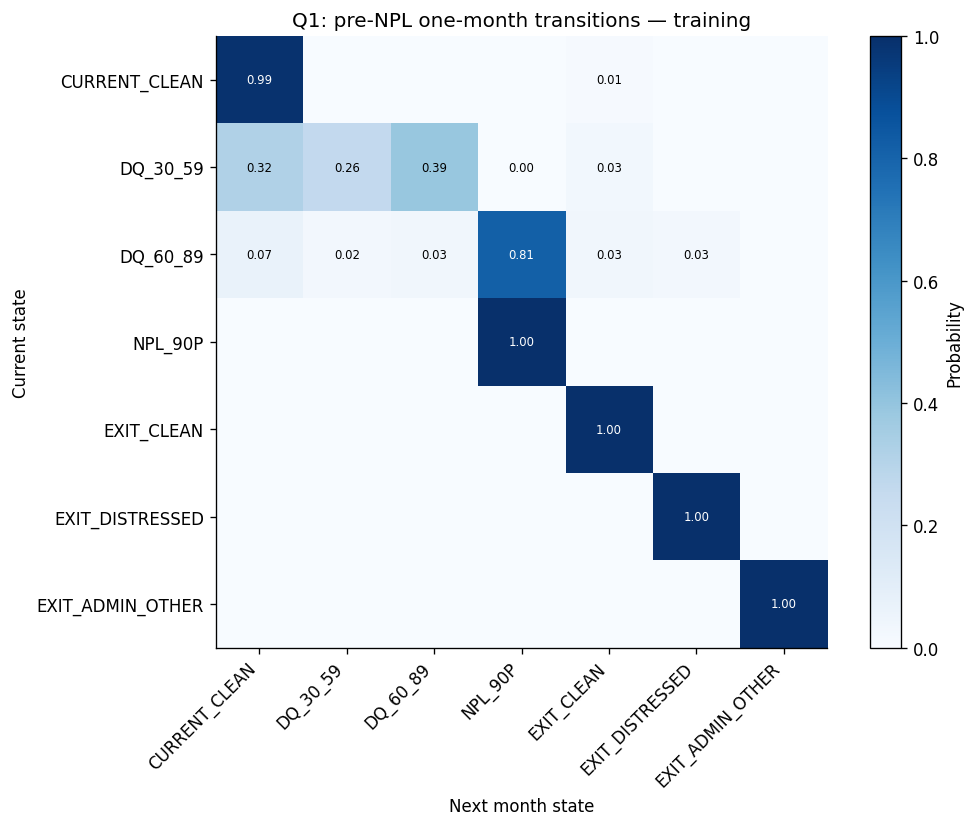

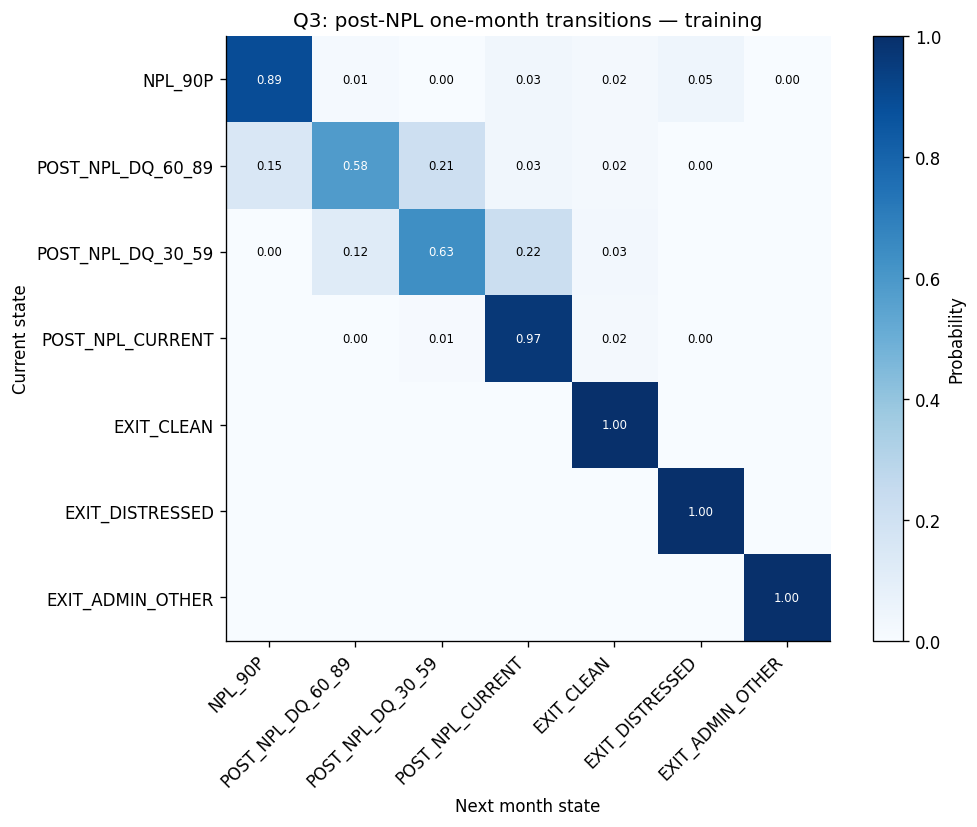

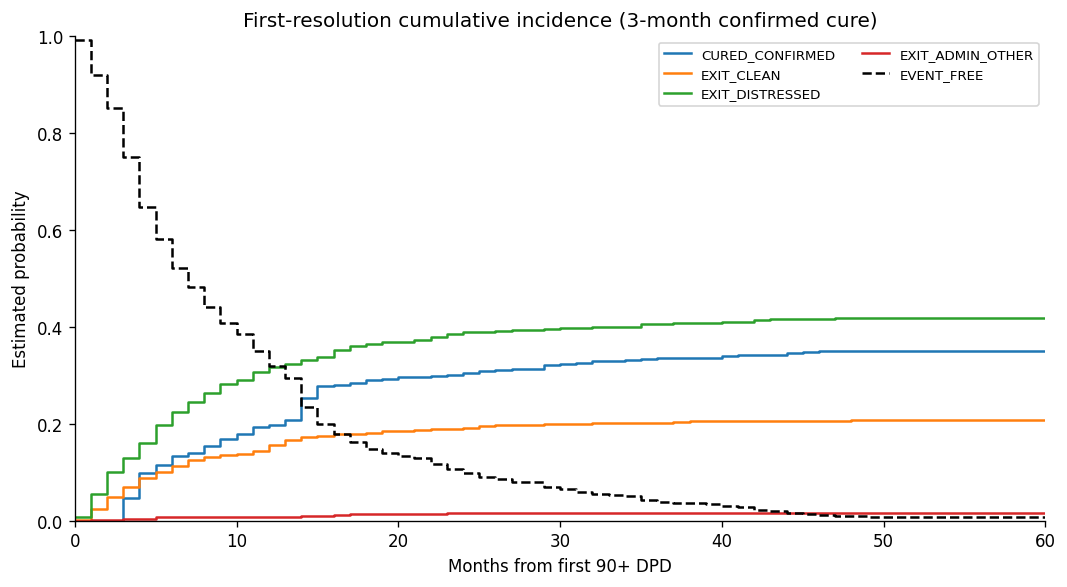

In [18]:
def plot_transition_heatmap(probability, title, filename):
    fig, ax = plt.subplots(figsize=(9, 7))
    image = ax.imshow(probability.to_numpy(), cmap="Blues", vmin=0, vmax=max(0.01, probability.to_numpy().max()))
    ax.set_xticks(range(len(probability.columns)), probability.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(probability.index)), probability.index)
    for i in range(len(probability.index)):
        for j in range(len(probability.columns)):
            value = probability.iloc[i, j]
            if value >= 0.001:
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if value > 0.5 * probability.to_numpy().max() else "black")
    ax.set_title(title)
    ax.set_xlabel("Next month state")
    ax.set_ylabel("Current state")
    fig.colorbar(image, ax=ax, label="Probability")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


plot_transition_heatmap(q1_probability, "Q1: pre-NPL one-month transitions — training", "q1_transition_heatmap.png")
plot_transition_heatmap(q3_probability, "Q3: post-NPL one-month transitions — training", "q3_transition_heatmap.png")

overall_curve = aj_curve(first_events)
fig, ax = plt.subplots(figsize=(9, 5))
for event in Q2_EVENTS:
    ax.step(overall_curve["time_m"], overall_curve[f"cif_{event}"], where="post", label=event)
ax.step(overall_curve["time_m"], overall_curve["event_free_probability"], where="post",
        label="EVENT_FREE", linestyle="--", color="black")
ax.set_xlim(0, min(60, max(overall_curve["time_m"].max(), 24)))
ax.set_ylim(0, 1)
ax.set_xlabel("Months from first 90+ DPD")
ax.set_ylabel("Estimated probability")
ax.set_title(f"First-resolution cumulative incidence ({PRIMARY_CURE_MONTHS}-month confirmed cure)")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "q2_first_resolution_cumulative_incidence.png", dpi=160, bbox_inches="tight")
plt.show()

## 17. Manifest, reproducibility record and interpretation boundary

In [19]:
output_files = sorted(path.name for path in OUTPUT_DIR.iterdir() if path.is_file())
manifest = {
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "notebook": "FNMA_Recovery_Multistate_Framework.ipynb",
    "script_version": "recovery_multistate_v5",
    "configuration": CONFIG,
    "inputs": {
        "untruncated_source": file_fingerprint(SOURCE_PATH),
        "accepted_split": file_fingerprint(SPLIT_PATH),
        "ews_predictions": file_fingerprint(prediction_path) if prediction_path else None,
    },
    "population": {
        "source_rows": len(df),
        "source_loans": int(df["Loan Number"].nunique()),
        "npl_loans_all_source": int(terminal["first_npl"].notna().sum()),
        "npl_loans_in_accepted_split": len(first_events),
        "data_end": str(DATA_END.date()),
    },
    "selected_q3_specification": SELECTED_Q3_SPECIFICATION,
    "ews_link": ews_status,
    "loss_severity": severity_status,
    "limitations": [
        "EWS-to-recovery comparisons are associative; no collections treatment is observed.",
        "EXIT_ADMIN_OTHER ends Fannie observation but may not terminate the underlying borrower obligation.",
        "Distressed/liquidation exit does not itself prove positive net credit loss.",
        "Realised net-loss severity, if available, is not labelled LGD or IFRS 9 ECL.",
        "Aalen-Johansen handles competing events and right censoring under its assumptions; it does not remove history dependence.",
        "Era differences are descriptive and unadjusted; loan composition and calendar conditions both vary across eras.",
        "Calendar-specific validation is a retrospective held-out backtest and does not identify an unseen future regime.",
        "Exit records dated before a later first-NPL event are audited and excluded from post-NPL resolution; the later NPL loan remains at risk and is censored unless another valid exit is observed.",
    ],
    "outputs": output_files,
}
write_json(manifest, "manifest.json")

summary = pd.DataFrame([
    {"item": "Assigned first-NPL loans", "value": len(first_events)},
    {"item": "Primary cure definition", "value": f"{PRIMARY_CURE_MONTHS} consecutive Current months"},
    {"item": "Selected Q3 specification", "value": SELECTED_Q3_SPECIFICATION},
    {"item": "Q1 training transitions", "value": len(q1_train)},
    {"item": "Q3 training transitions", "value": len(q3_train)},
    {"item": "EWS link", "value": ews_status["status"]},
    {"item": "Loss severity", "value": severity_status["status"]},
    {"item": "Output directory", "value": str(OUTPUT_DIR)},
])
display(Markdown("## Run completed"))
display(summary)
print(f"Saved {len(output_files) + 1} auditable outputs to {OUTPUT_DIR}")

## Run completed

,item,value
0,Assigned first-NPL loans,1455
1,Primary cure definition,3 consecutive Current months
2,Selected Q3 specification,duration_specific
3,Q1 training transitions,3012447
4,Q3 training transitions,18924
5,EWS link,completed
6,Loss severity,restricted_descriptive_completed
7,Output directory,/content/drive/MyDrive/FIP_NPL_Project/model_o...


Saved 43 auditable outputs to /content/drive/MyDrive/FIP_NPL_Project/model_outputs_recovery_multistate


## Methodological references

- Jarrow, Lando & Turnbull (1997), *A Markov Model for the Term Structure of Credit Risk Spreads* — canonical finite-state credit application.
- Lando & Skødeberg (2002), *Analyzing rating transitions and rating drift with continuous observations* — non-Markov credit-state behaviour.
- Aalen & Johansen (1978), *An empirical transition matrix for non-homogeneous Markov chains based on censored observations* — product-limit transition estimation.
- Chamboko & Bravo (2020), *A Multi-State Approach to Modelling Intermediate Events and Multiple Mortgage Loan Outcomes* — mortgage cure and alternative outcomes.
- Bocchio, Crook & Andreeva (2023), *The impact of macroeconomic scenarios on recurrent delinquency* — repeated mortgage delinquency and macro-conditioned transitions.
- Office of the Comptroller of the Currency, *Estimating Conditional Mortgage Delinquency Transition Matrices* — mortgage transition forecasting and limits of the simple Markov assumption.
- Fannie Mae, *Multifamily Loan Performance Data Attribute Glossary and File Layout* and *Multifamily Data Dynamics FAQs* — source-field and liquidation-code definitions.

The ECL boundary follows IFRS 9's definition of expected credit losses as probability-weighted present values of expected cash shortfalls. This notebook supplies analytical components and decision triggers, not the lender-specific contractual cash flows, effective interest rate, staging policy, scenario weights or accounting governance required for a complete implementation.